**Ingeniería de Datos**



In [135]:
import warnings

warnings.filterwarnings("ignore")

#import janitor
import matplotlib.pyplot as plt
import missingno
import numpy as np
import pyreadr
import seaborn as sns

import pandas as pd



In [136]:
%run pandas-missing-extension.ipynb

In [137]:
nhanes_raw_df = pd.read_csv("nhanes.csv")
nhanes_raw_df


,SEQN,general_health_condition,ever_breastfed_or_fed_breastmilk,age_stopped_breastfeedingdays,age_first_fed_formuladays,age_stopped_receiving_formuladays,age_started_other_foodbeverage,age_first_fed_milkdays,type_of_milk_first_fed_whole_milk,type_of_milk_first_fed2_milk,...,days_smoked_cigs_during_past30_days,avg_cigarettesday_during_past30_days,tried_to_quit_smoking,times_stopped_smoking_cigarettes,how_long_were_you_able_to_stop_smoking,unit_of_measure_dayweekmonthyear_2_smq,current_selfreported_height_inches,current_selfreported_weight_pounds,tried_to_lose_weight_in_past_year,times_lost10_lbs_or_more_to_lose_weight
0,93703.0,NaN,1.0,273.0,1.0,365.0,152.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,93704.0,NaN,1.0,60.0,3.0,365.0,126.0,365.0,Whole or regular milk,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,93705.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,63.0,165.0,0.0,11 times or more
3,93706.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,68.0,145.0,0.0,Never
4,93707.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,102952.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,117.0,0.0,Never
8362,102953.0,Fair or,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,65.0,218.0,0.0,Never
8363,102954.0,Good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,66.0,150.0,0.0,Never
8364,102955.0,Very good,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [138]:
variables = [
    "total_number_of_people_in_the_family",
    "age_in_years_at_screening",
    "gender",
    "taking_insulin_now",
    "weight_kg",
    "standing_height_cm",
    "blood_mercury_total_ugl",
    "total_monounsaturated_fatty_acids_gm_dr1_tot",
    "systolic_blood_pres3_rd_rdg_mm_hg",
    "carbohydrate_gm_dr2_tot",
    "waist_circumference_cm",
    "general_health_condition"
]
df_subset = nhanes_raw_df[variables]

df_subset



,total_number_of_people_in_the_family,age_in_years_at_screening,gender,taking_insulin_now,weight_kg,standing_height_cm,blood_mercury_total_ugl,total_monounsaturated_fatty_acids_gm_dr1_tot,systolic_blood_pres3_rd_rdg_mm_hg,carbohydrate_gm_dr2_tot,waist_circumference_cm,general_health_condition
0,5,2.0,Female,0.0,13.7,88.6,NaN,NaN,NaN,NaN,48.2,NaN
1,4,2.0,Male,0.0,13.9,94.2,0.47,14.333,NaN,229.69,50.0,NaN
2,1,66.0,Female,0.0,79.5,158.3,1.07,16.432,202.0,147.49,101.8,Good
3,5,18.0,Male,0.0,66.3,175.7,10.64,45.805,108.0,NaN,79.3,Very good
4,7 or more people in the Family,13.0,Male,0.0,45.4,158.4,0.20,33.712,128.0,153.12,64.1,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
8361,2,70.0,Female,0.0,49.0,156.5,0.65,15.611,140.0,174.17,82.2,Very good
8362,1,42.0,Male,0.0,97.4,164.9,0.62,44.604,116.0,NaN,114.8,Fair or
8363,7 or more people in the Family,41.0,Female,0.0,69.1,162.6,2.08,23.098,114.0,208.83,86.4,Good
8364,4,14.0,Female,0.0,111.9,156.6,0.20,11.406,114.0,241.63,113.5,Very good


In [139]:
#Nulos totales por variable

nulos_totales_por_variable = df_subset.isnull().sum()

nulos_totales_por_variable

total_number_of_people_in_the_family               0
age_in_years_at_screening                          0
gender                                             0
taking_insulin_now                                 1
weight_kg                                        124
standing_height_cm                               350
blood_mercury_total_ugl                          853
total_monounsaturated_fatty_acids_gm_dr1_tot    1081
systolic_blood_pres3_rd_rdg_mm_hg               1828
carbohydrate_gm_dr2_tot                         2043
waist_circumference_cm                           765
general_health_condition                        2402
dtype: int64

In [140]:
df_subset.missing.number_missing()

#nulos totales

#nulos explicitos son 9447

9447

In [141]:
df_subset.missing.missing_variable_summary()


#Porcentaje de nulos por variable, el que más nulos tiene tanto por cantidad como por relación es general_health_condition

,variable,n_missing,n_cases,pct_missing
0,total_number_of_people_in_the_family,0,8366,0.000000
1,age_in_years_at_screening,0,8366,0.000000
2,gender,0,8366,0.000000
3,taking_insulin_now,1,8366,0.011953
4,weight_kg,124,8366,1.482190
5,standing_height_cm,350,8366,4.183600
6,blood_mercury_total_ugl,853,8366,10.196032
7,total_monounsaturated_fatty_acids_gm_dr1_tot,1081,8366,12.921348
8,systolic_blood_pres3_rd_rdg_mm_hg,1828,8366,21.850347
9,carbohydrate_gm_dr2_tot,2043,8366,24.420273


In [142]:
#Catnidad de variables nulas por registro (fila)
df_subset.missing.missing_case_summary()

,case,n_missing,pct_missing
0,0,5,35.714286
1,1,2,14.285714
2,2,0,0.000000
3,3,1,7.142857
4,4,0,0.000000
...,...,...,...
8361,8361,0,0.000000
8362,8362,1,7.142857
8363,8363,0,0.000000
8364,8364,0,0.000000


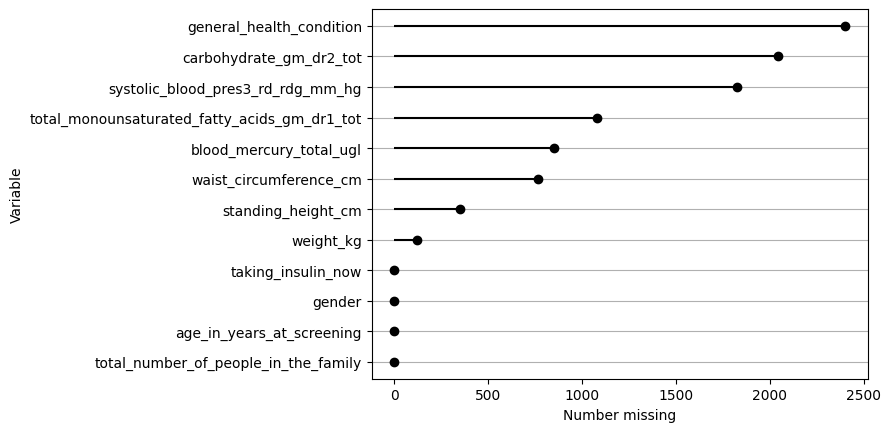

In [143]:
df_subset.missing.missing_variable_plot()

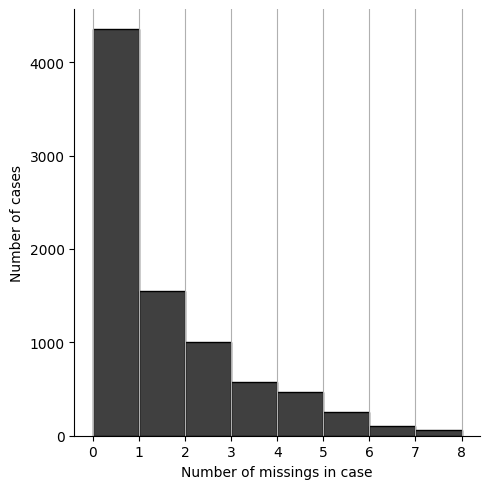

In [144]:
df_subset.missing.missing_case_plot()

#4000 filas sin ningún valor nulo

# muy pocas filas tienen 7 valores nulos

<Axes: >

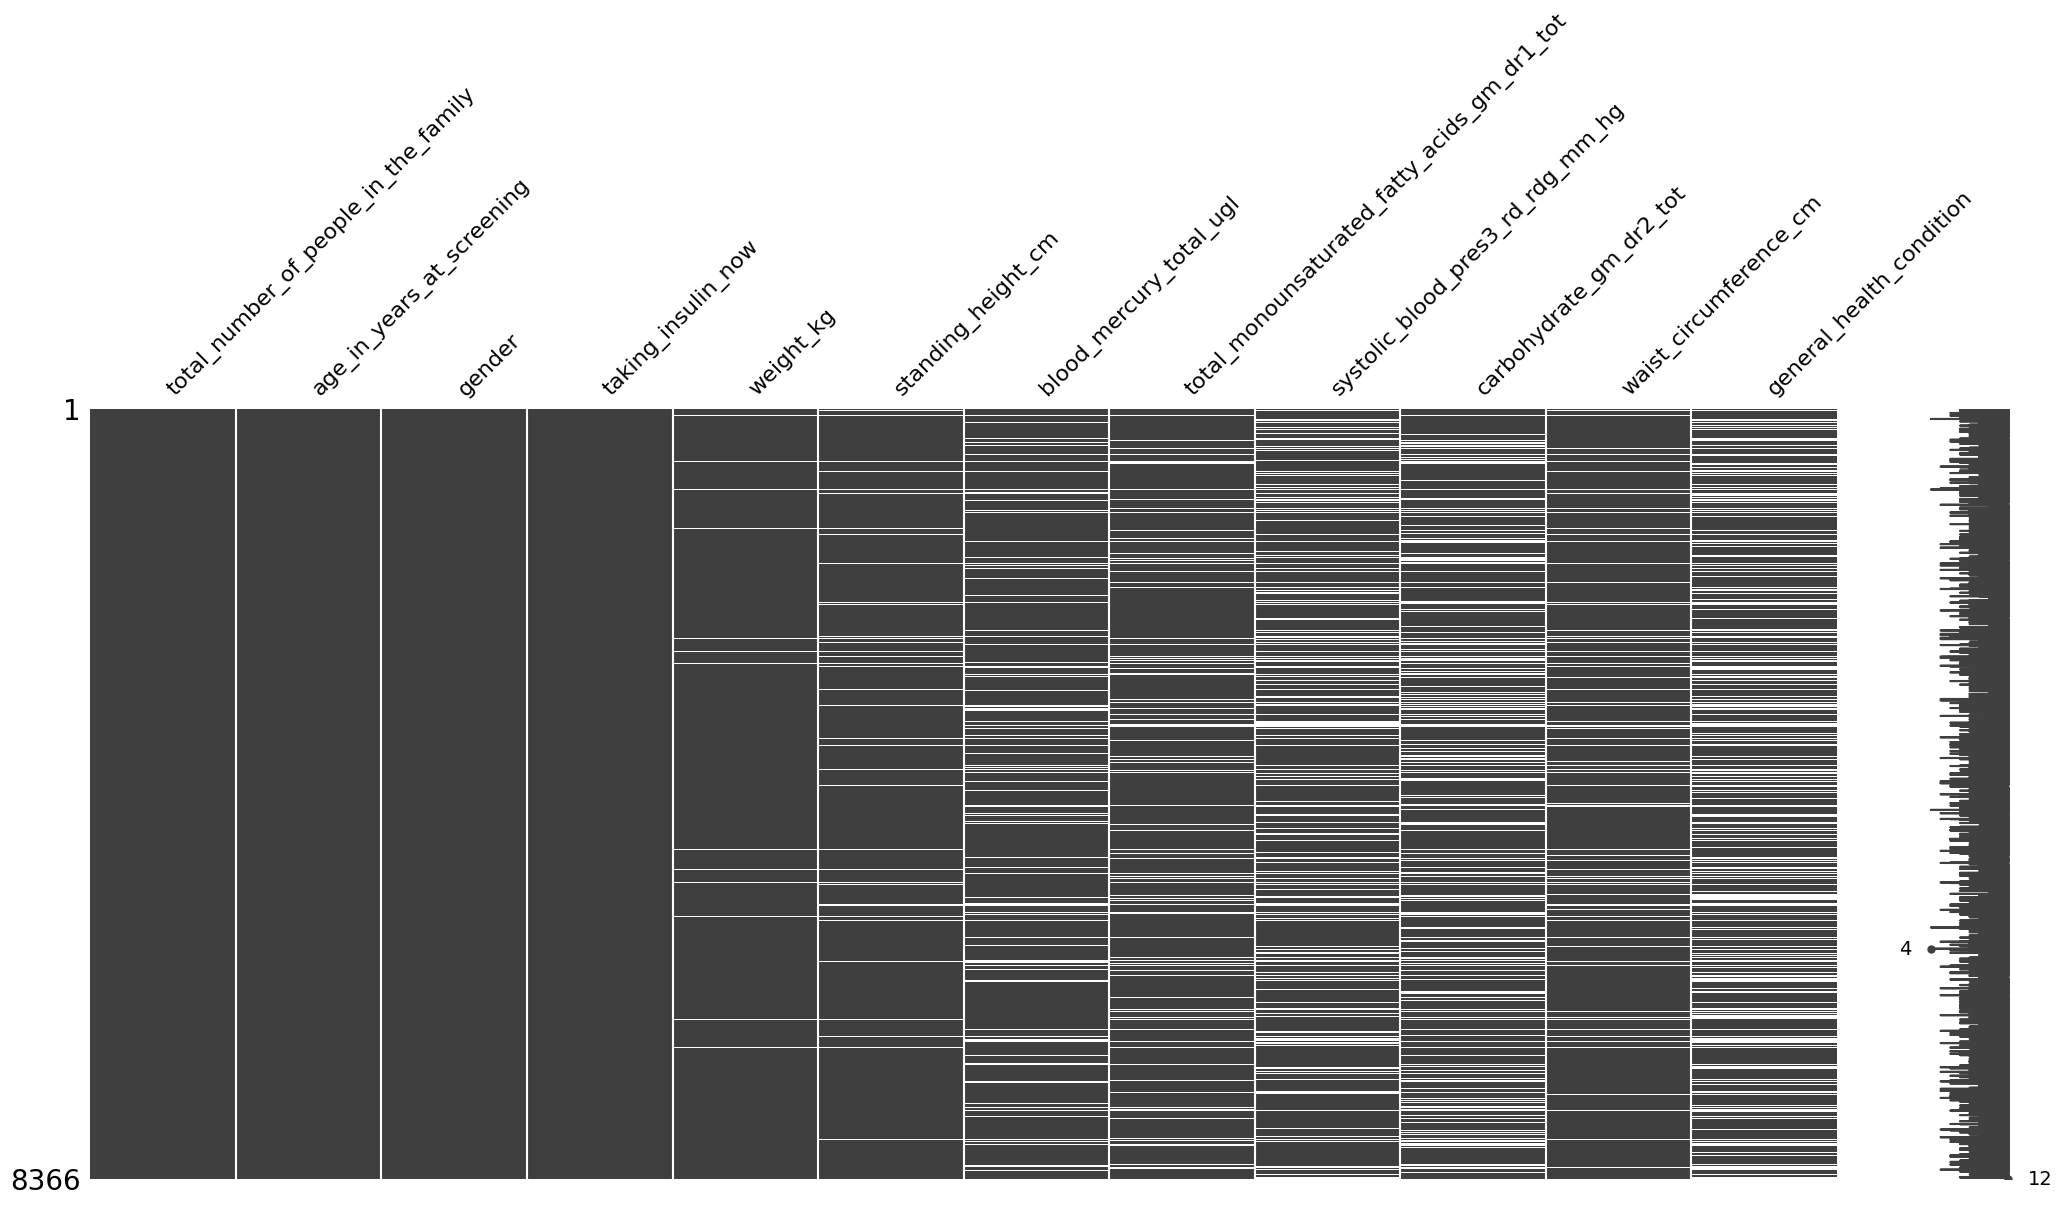

In [145]:
missingno.matrix(df_subset)

#Linea blanca- Valor nulo, las primeras 4 columnas no tienen nulos

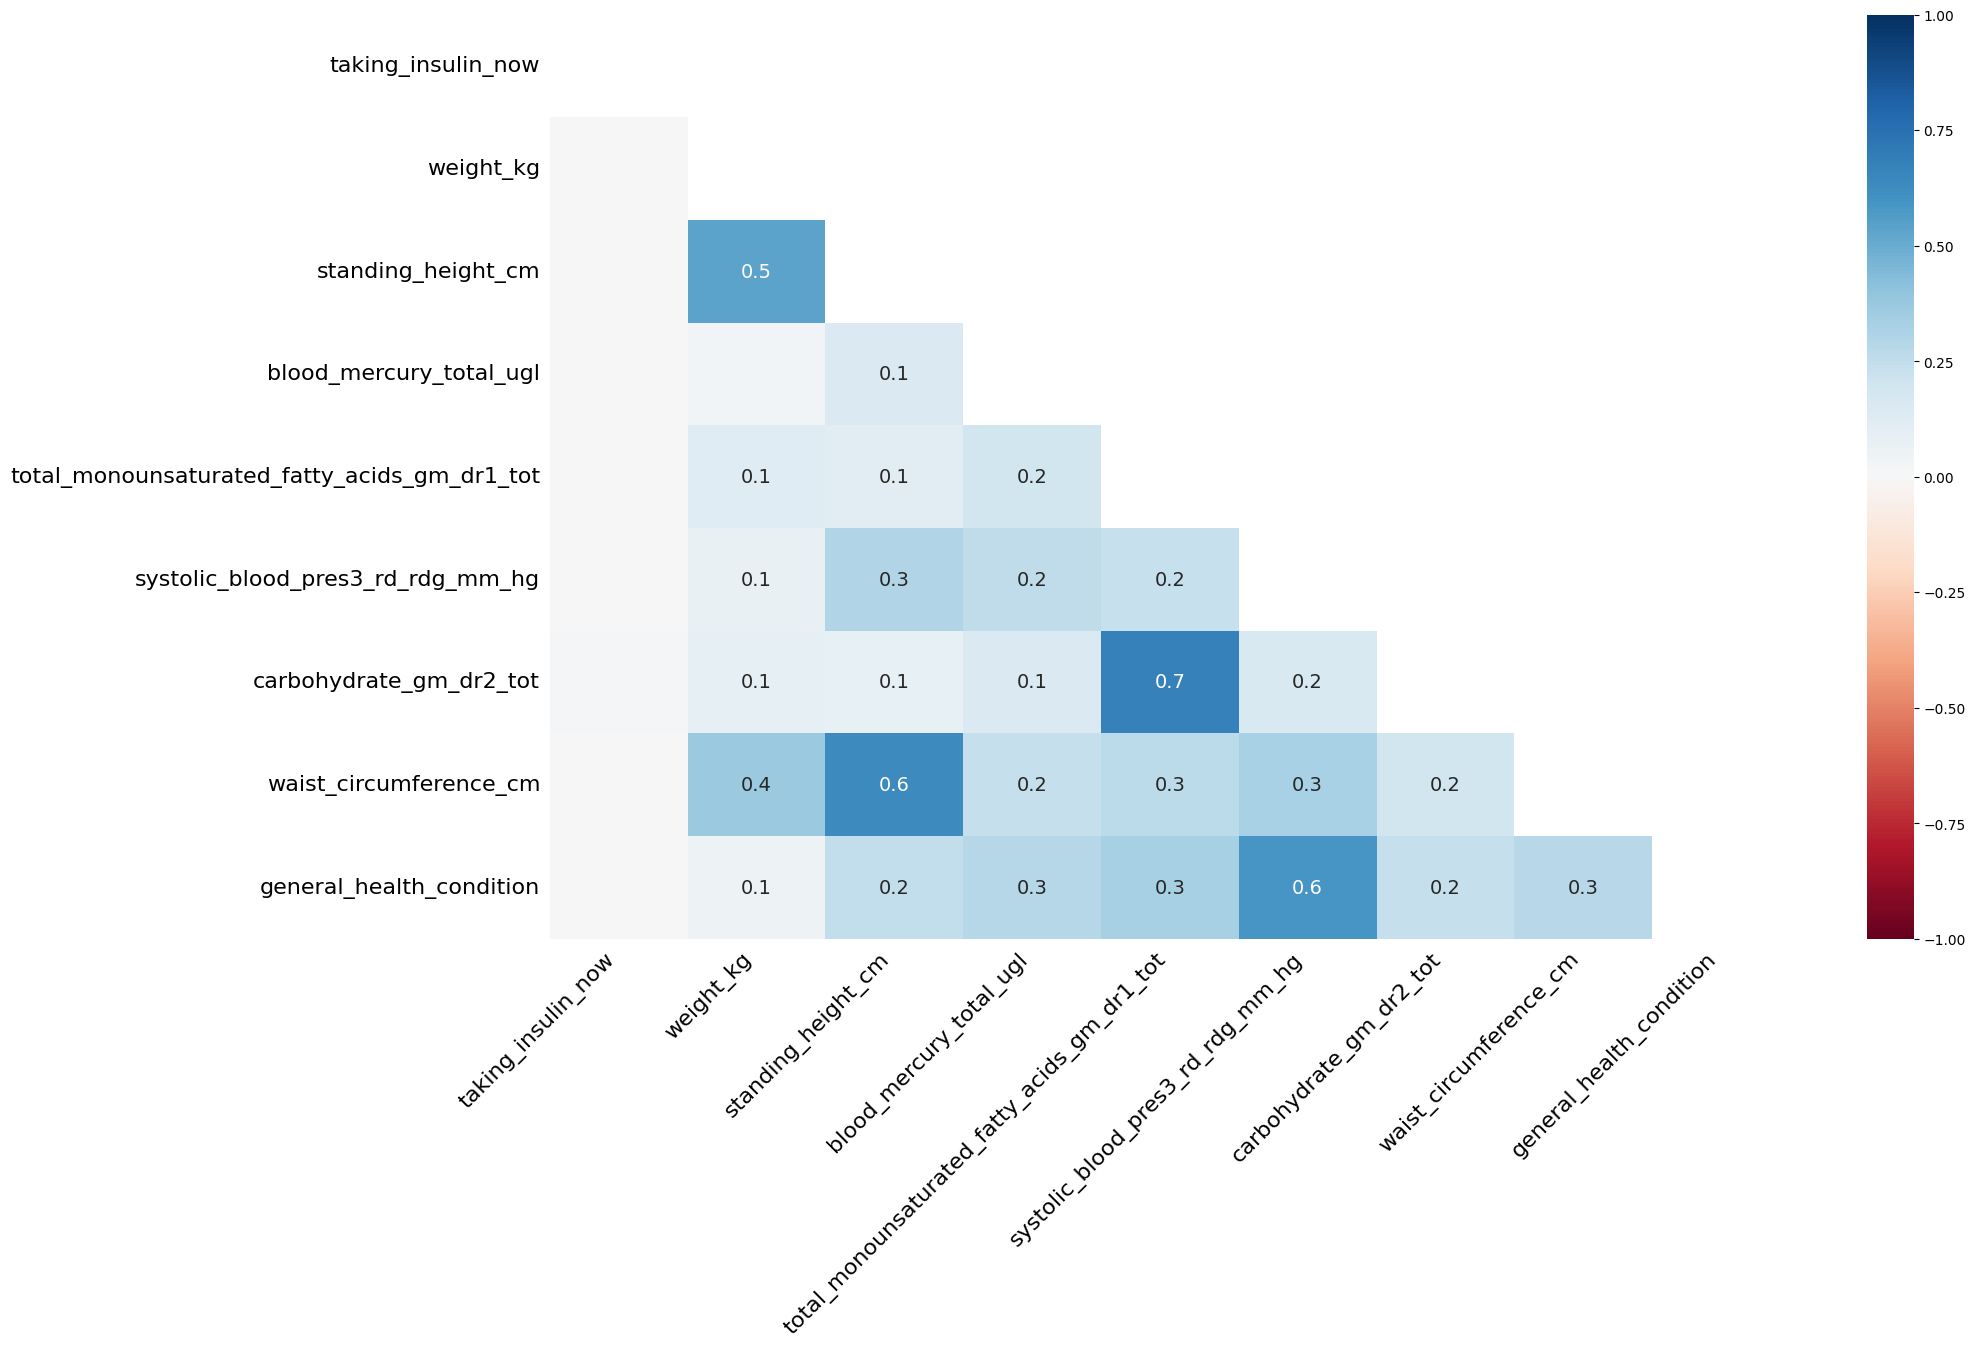

In [146]:
missingno.heatmap(df=df_subset
                  )

plt.show()


#Hay correlación alta de nulidad entre registros de standing_height_cm y weight_kg
# Hay correlación alta de nulidad entre carbohydrate_gm_dr2_tot y total_monounsaturated_fatty_acids_gm_dr1_tot
#hay correlación alta de nulidad entre waist_circumference_cm y standing_height_cm
#hay correlación alta de nulidad entre general_health_condition y systolic_blood_pres3_rd_rdg_mm_hg



In [147]:

#Método info determina la cantidad de registros, los tipos de variable y la cantidad de datos no nulos por variable.
df_subset.info()


<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   total_number_of_people_in_the_family          8366 non-null   str    
 1   age_in_years_at_screening                     8366 non-null   float64
 2   gender                                        8366 non-null   str    
 3   taking_insulin_now                            8365 non-null   float64
 4   weight_kg                                     8242 non-null   float64
 5   standing_height_cm                            8016 non-null   float64
 6   blood_mercury_total_ugl                       7513 non-null   float64
 7   total_monounsaturated_fatty_acids_gm_dr1_tot  7285 non-null   float64
 8   systolic_blood_pres3_rd_rdg_mm_hg             6538 non-null   float64
 9   carbohydrate_gm_dr2_tot                       6323 non-null   float64
 10 

In [148]:
#Comportamiento estadístico de las variables
#El metodo describe() de pandas devuelve un resumen estadístico de las variables numéricas, incluyendo la cantidad de datos no nulos, la media, la desviación estándar, los valores mínimo y máximo, y los percentiles.
 

#unique es numero de cxategorias distintas que tiene cada variable

# top es la categoría más frecuente y freq es la cantidad de veces que aparece esa categoría más frecuente

In [149]:
#categóricas
df_subset.describe(include='object').transpose()

,count,unique,top,freq
total_number_of_people_in_the_family,8366,7,4,1658
gender,8366,2,Female,4272
general_health_condition,5964,5,Good,2454


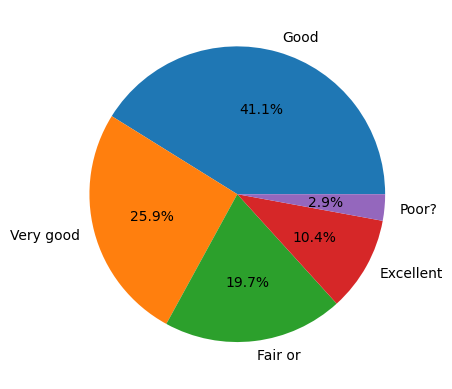

In [150]:
plt.pie(x = df_subset.general_health_condition.value_counts(), labels = df_subset.general_health_condition.value_counts().index, autopct='%1.1f%%')
plt.show()

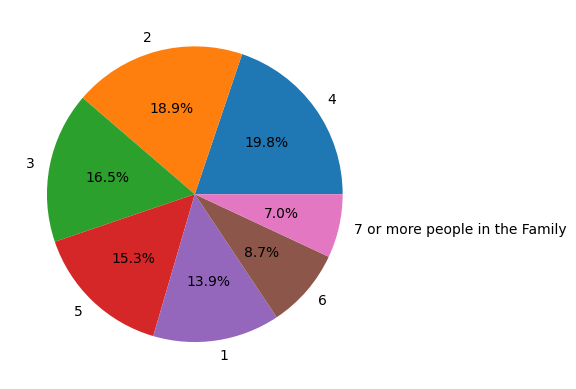

In [151]:
plt.pie(x = df_subset.total_number_of_people_in_the_family.value_counts(), labels = df_subset.total_number_of_people_in_the_family.value_counts().index, autopct='%1.1f%%')
plt.show()

In [152]:
#numericas

#numericas
df_subset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age_in_years_at_screening,8366.0,35.830026,24.905061,1.000000e+00,12.000,33.000,59.000,80.000
taking_insulin_now,8365.0,0.029528,0.169291,0.000000e+00,0.000,0.000,0.000,1.000
weight_kg,8242.0,67.499260,31.377152,8.300000e+00,48.700,69.200,86.500,242.600
standing_height_cm,8016.0,156.593401,22.257858,7.830000e+01,151.400,161.900,171.200,197.700
blood_mercury_total_ugl,7513.0,1.142698,2.269646,2.000000e-01,0.200,0.510,1.120,63.640
total_monounsaturated_fatty_acids_gm_dr1_tot,7285.0,27.468689,17.076665,5.397605e-79,15.784,23.979,35.177,200.097
systolic_blood_pres3_rd_rdg_mm_hg,6538.0,121.239217,20.277635,7.200000e+01,106.000,118.000,132.000,238.000
carbohydrate_gm_dr2_tot,6323.0,221.468692,113.569490,5.397605e-79,144.680,204.190,275.990,1455.450
waist_circumference_cm,7601.0,89.928851,22.805093,4.000000e+01,73.900,91.200,105.300,169.500


In [153]:
#Primeramente sí hay valores nulos explícitos (9447), pero tambien podríamos argumentar que hay datos nulos implícitos
#Por ejemplo un peso de 242.6kg, que es un outlier
#Tambien la parte del mercurio en la sangre máximo está muy por encima de su media o su mediana (o el percentil 75 y 25)
# total_monounsaturated_fatty_acids tiene un vcalor máximo muy alejado de su media y mediana, podría tambien ser un outlier
# saystolic_blood_pres3_rd_rdg_mm_hg tiene un valor máximo muy alejado de su media y mediana, podría tambien ser un outlier

#La ingesta de carbohidratos tambien



<Axes: xlabel='weight_kg'>

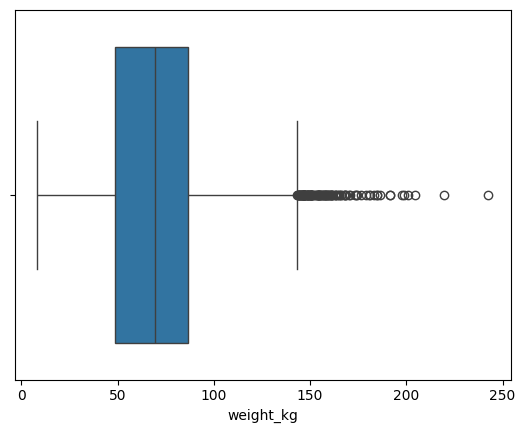

In [154]:
sns.boxplot(data = df_subset, x = "weight_kg")

#Aca se puede ver que esta variable está llena de atípicos ( por arriba de 150 kilos)

<Axes: xlabel='blood_mercury_total_ugl'>

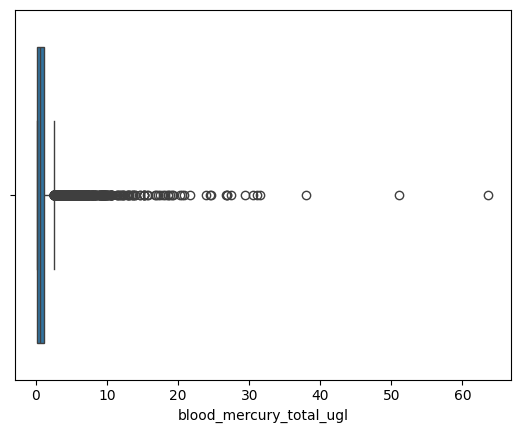

In [155]:
sns.boxplot(data = df_subset, x = "blood_mercury_total_ugl")

#LLena de outliers

<Axes: xlabel='total_monounsaturated_fatty_acids_gm_dr1_tot'>

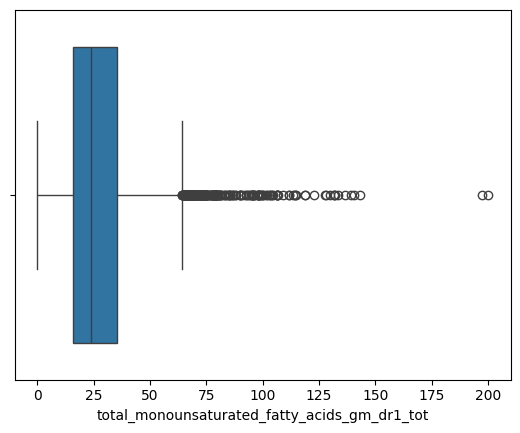

In [156]:
sns.boxplot(data = df_subset, x = "total_monounsaturated_fatty_acids_gm_dr1_tot")

#Llena de outliers

<Axes: xlabel='carbohydrate_gm_dr2_tot'>

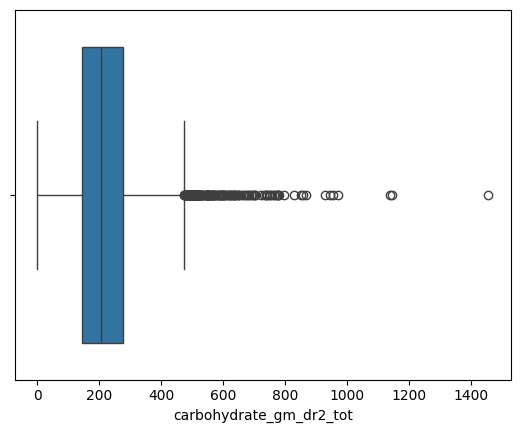

In [157]:
sns.boxplot(data = df_subset, x = "carbohydrate_gm_dr2_tot")


#Llena de outliers

<Axes: xlabel='systolic_blood_pres3_rd_rdg_mm_hg'>

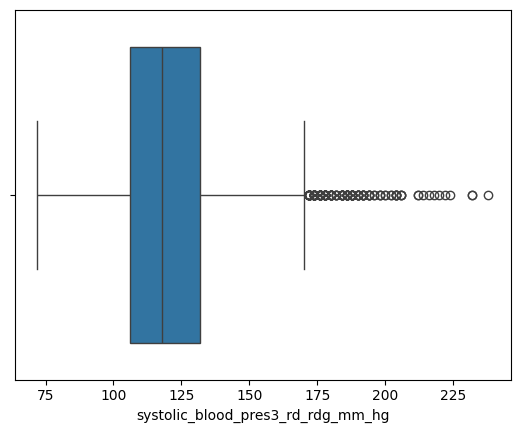

In [158]:
sns.boxplot(data = df_subset, x = "systolic_blood_pres3_rd_rdg_mm_hg")


In [159]:
# A pesar de que muchas variables parecen tener outliers, estos son datos médicos entonces tiene sentido que existan valores fuera de lo normal
# Como personas con obesidad mórbida o intoxicadas con mercurio.

In [160]:
#Imputación por medidas de tendencia central
#Como hay tanto outlier en las numericas voy a usar la mediana
df_subset_copy_df = df_subset.copy()

columnas_a_imputar = [
    'weight_kg',
    'standing_height_cm',
    'blood_mercury_total_ugl',
    'total_monounsaturated_fatty_acids_gm_dr1_tot',
    'systolic_blood_pres3_rd_rdg_mm_hg',
    'carbohydrate_gm_dr2_tot',
    'waist_circumference_cm'
]

for col in columnas_a_imputar:
    mediana = df_subset_copy_df[col].median().round(2)
    df_subset_copy_df[col] = df_subset_copy_df[col].fillna(mediana)


moda_health = df_subset_copy_df['general_health_condition'].mode()[0]

# Imputar los valores nulos con la moda
df_subset_copy_df['general_health_condition'] = df_subset_copy_df['general_health_condition'].fillna(moda_health)


df_subset_copy_df

,total_number_of_people_in_the_family,age_in_years_at_screening,gender,taking_insulin_now,weight_kg,standing_height_cm,blood_mercury_total_ugl,total_monounsaturated_fatty_acids_gm_dr1_tot,systolic_blood_pres3_rd_rdg_mm_hg,carbohydrate_gm_dr2_tot,waist_circumference_cm,general_health_condition
0,5,2.0,Female,0.0,13.7,88.6,0.51,23.980,118.0,204.19,48.2,Good
1,4,2.0,Male,0.0,13.9,94.2,0.47,14.333,118.0,229.69,50.0,Good
2,1,66.0,Female,0.0,79.5,158.3,1.07,16.432,202.0,147.49,101.8,Good
3,5,18.0,Male,0.0,66.3,175.7,10.64,45.805,108.0,204.19,79.3,Very good
4,7 or more people in the Family,13.0,Male,0.0,45.4,158.4,0.20,33.712,128.0,153.12,64.1,Good
...,...,...,...,...,...,...,...,...,...,...,...,...
8361,2,70.0,Female,0.0,49.0,156.5,0.65,15.611,140.0,174.17,82.2,Very good
8362,1,42.0,Male,0.0,97.4,164.9,0.62,44.604,116.0,204.19,114.8,Fair or
8363,7 or more people in the Family,41.0,Female,0.0,69.1,162.6,2.08,23.098,114.0,208.83,86.4,Good
8364,4,14.0,Female,0.0,111.9,156.6,0.20,11.406,114.0,241.63,113.5,Very good


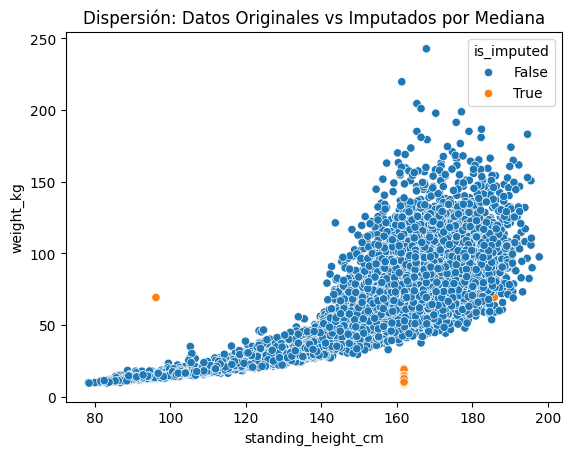

In [161]:
import matplotlib.pyplot as plt


(
    df_subset[['standing_height_cm', 'weight_kg']]
    .missing.bind_shadow_matrix(True, False, suffix='_imp')
    .assign(
        
        standing_height_cm=lambda df: df.standing_height_cm.fillna(df.standing_height_cm.median().round(2)),
        weight_kg=lambda df: df.weight_kg.fillna(df.weight_kg.median().round(2))
    )
    .missing.scatter_imputation_plot(x='standing_height_cm', y='weight_kg')
)

plt.title("Dispersión: Datos Originales vs Imputados por Mediana")
plt.show()



#Lo amarillo son los datos imputados, la relación altura-peso es coherente para todos los datos
#Menos para los imputados que se ve que no siguen la tendencia de los datos originales, como ese dato de altura 95cm 7 pesa 70kg



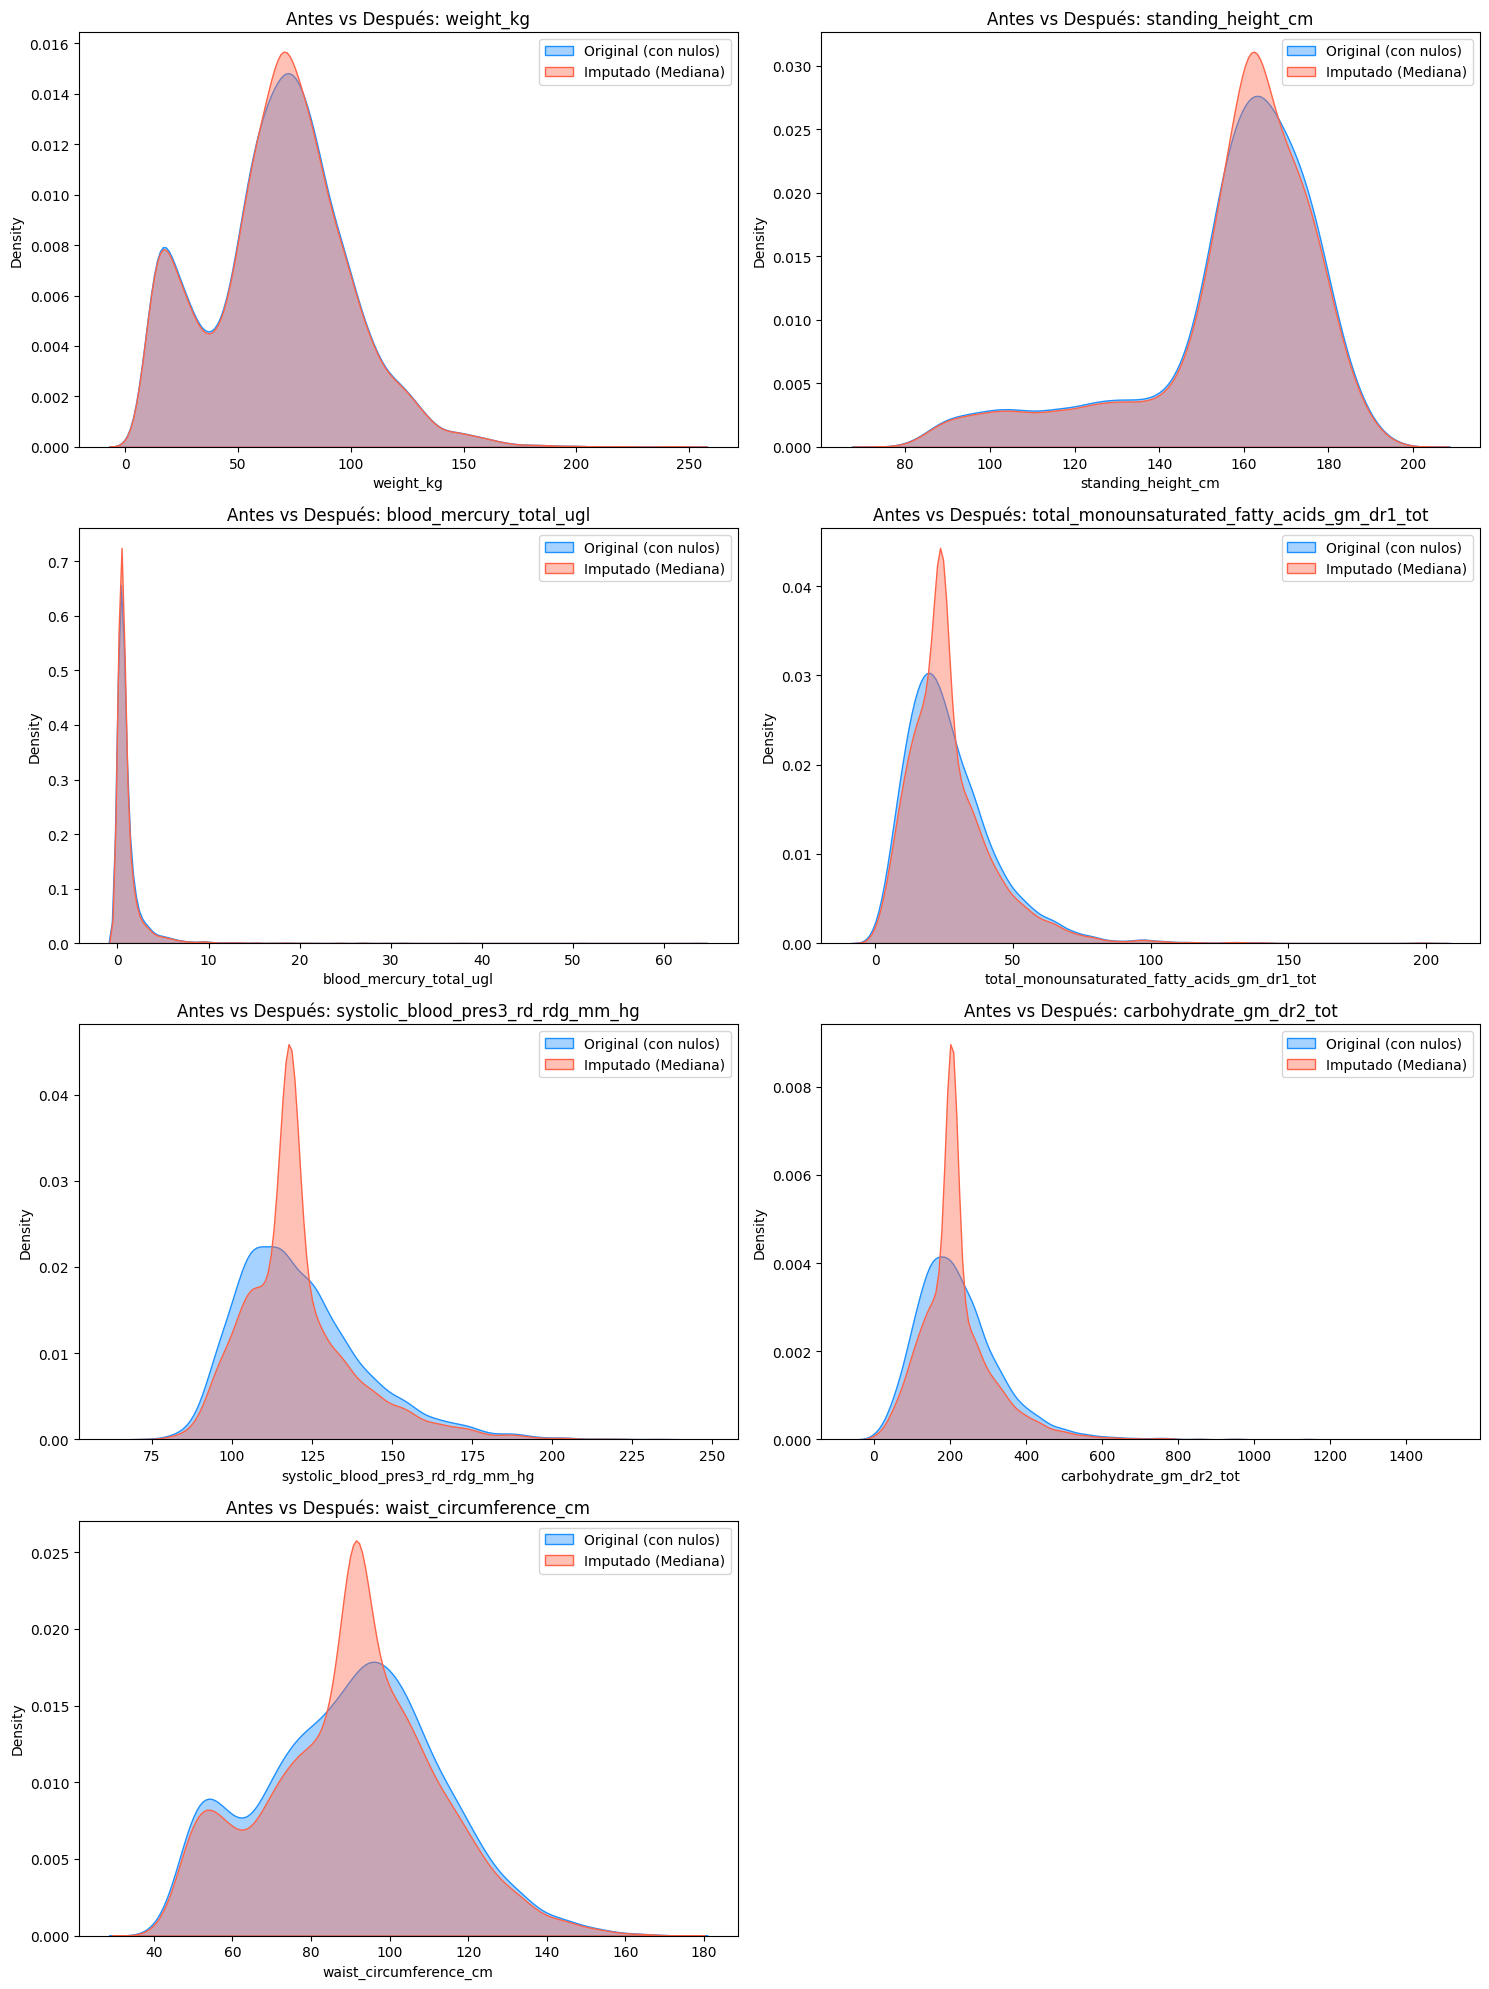

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten() 

for i, col in enumerate(columnas_a_imputar):
    sns.kdeplot(data=df_subset, x=col, ax=axes[i], label='Original (con nulos)', color='dodgerblue', fill=True, alpha=0.4)
    
    sns.kdeplot(data=df_subset_copy_df, x=col, ax=axes[i], label='Imputado (Mediana)', color='tomato', fill=True, alpha=0.4)
    
    axes[i].set_title(f'Antes vs Después: {col}', fontsize=12)
    axes[i].legend()

# Ocultar el último gráfico vacío (porque son 7 variables y tenemos 8 espacios)
fig.delaxes(axes[7])

plt.tight_layout()
plt.show()



# Para no tener que estar graficando cada uno de los scatter plots, prefiero graficar las distribuciones de cada variable antes y después de la imputación.

In [163]:
"""

Como se puede ver, la imputación por medidas de tendencia central no 
es la mejor, ya que altera la función de densidad de probabilidad de manera significativa
para waist_circumference_cm, carbohydrate_gm_dr2_tot,systolic_blood_pres3_rd_rdg_mm_hg y total_monounsaturated_fatty_acids_gm_dr1_tot.
"""

'\n\nComo se puede ver, la imputación por medidas de tendencia central no \nes la mejor, ya que altera la función de densidad de probabilidad de manera significativa\npara waist_circumference_cm, carbohydrate_gm_dr2_tot,systolic_blood_pres3_rd_rdg_mm_hg y total_monounsaturated_fatty_acids_gm_dr1_tot.\n'

In [164]:
#Imputacion por modelo de regresion
#imputacion por vecindad
#imputación por MICE

"""

 La unica columna categorica con nulos es general_health_condition.
 
"""




'\n\n La unica columna categorica con nulos es general_health_condition.\n\n'

In [165]:
import pandas as pd
import numpy as np
import sklearn.compose
import sklearn.preprocessing

df_knn_base = df_subset.copy()

columna_a_codificar = ['general_health_condition']

encoder = sklearn.preprocessing.OrdinalEncoder(encoded_missing_value=np.nan)

categorical_transformer = sklearn.compose.make_column_transformer(
    (encoder, columna_a_codificar),
    remainder='passthrough', 
    verbose_feature_names_out=False 
)


categorical_transformer.set_output(transform="pandas")
df_subset_transformed_df = categorical_transformer.fit_transform(df_knn_base)

df_subset_transformed_df

,general_health_condition,total_number_of_people_in_the_family,age_in_years_at_screening,gender,taking_insulin_now,weight_kg,standing_height_cm,blood_mercury_total_ugl,total_monounsaturated_fatty_acids_gm_dr1_tot,systolic_blood_pres3_rd_rdg_mm_hg,carbohydrate_gm_dr2_tot,waist_circumference_cm
0,NaN,5,2.0,Female,0.0,13.7,88.6,NaN,NaN,NaN,NaN,48.2
1,NaN,4,2.0,Male,0.0,13.9,94.2,0.47,14.333,NaN,229.69,50.0
2,2.0,1,66.0,Female,0.0,79.5,158.3,1.07,16.432,202.0,147.49,101.8
3,4.0,5,18.0,Male,0.0,66.3,175.7,10.64,45.805,108.0,NaN,79.3
4,2.0,7 or more people in the Family,13.0,Male,0.0,45.4,158.4,0.20,33.712,128.0,153.12,64.1
...,...,...,...,...,...,...,...,...,...,...,...,...
8361,4.0,2,70.0,Female,0.0,49.0,156.5,0.65,15.611,140.0,174.17,82.2
8362,1.0,1,42.0,Male,0.0,97.4,164.9,0.62,44.604,116.0,NaN,114.8
8363,2.0,7 or more people in the Family,41.0,Female,0.0,69.1,162.6,2.08,23.098,114.0,208.83,86.4
8364,4.0,4,14.0,Female,0.0,111.9,156.6,0.20,11.406,114.0,241.63,113.5


In [ ]:
#Imputacion por vecindad
numeric_cols = df_subset_transformed_df.select_dtypes(include=[np.number]).columns


text_cols = df_subset_transformed_df.select_dtypes(exclude=[np.number]).columns
knn_imputer = sklearn.impute.KNNImputer()
imputado_numerico = pd.DataFrame(
    knn_imputer.fit_transform(df_subset_transformed_df[numeric_cols]),
    columns=numeric_cols,
    index=df_subset_transformed_df.index
)

imputado_numerico['general_health_condition'] = imputado_numerico['general_health_condition'].round()
df_subset_knn_df = pd.concat([imputado_numerico, df_subset_transformed_df[text_cols]], axis=1)

df_subset_knn_df = df_subset_knn_df[df_subset_transformed_df.columns]
df_subset_knn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   general_health_condition                      8366 non-null   float64
 1   total_number_of_people_in_the_family          8366 non-null   str    
 2   age_in_years_at_screening                     8366 non-null   float64
 3   gender                                        8366 non-null   str    
 4   taking_insulin_now                            8366 non-null   float64
 5   weight_kg                                     8366 non-null   float64
 6   standing_height_cm                            8366 non-null   float64
 7   blood_mercury_total_ugl                       8366 non-null   float64
 8   total_monounsaturated_fatty_acids_gm_dr1_tot  8366 non-null   float64
 9   systolic_blood_pres3_rd_rdg_mm_hg             8366 non-null   float64
 10 

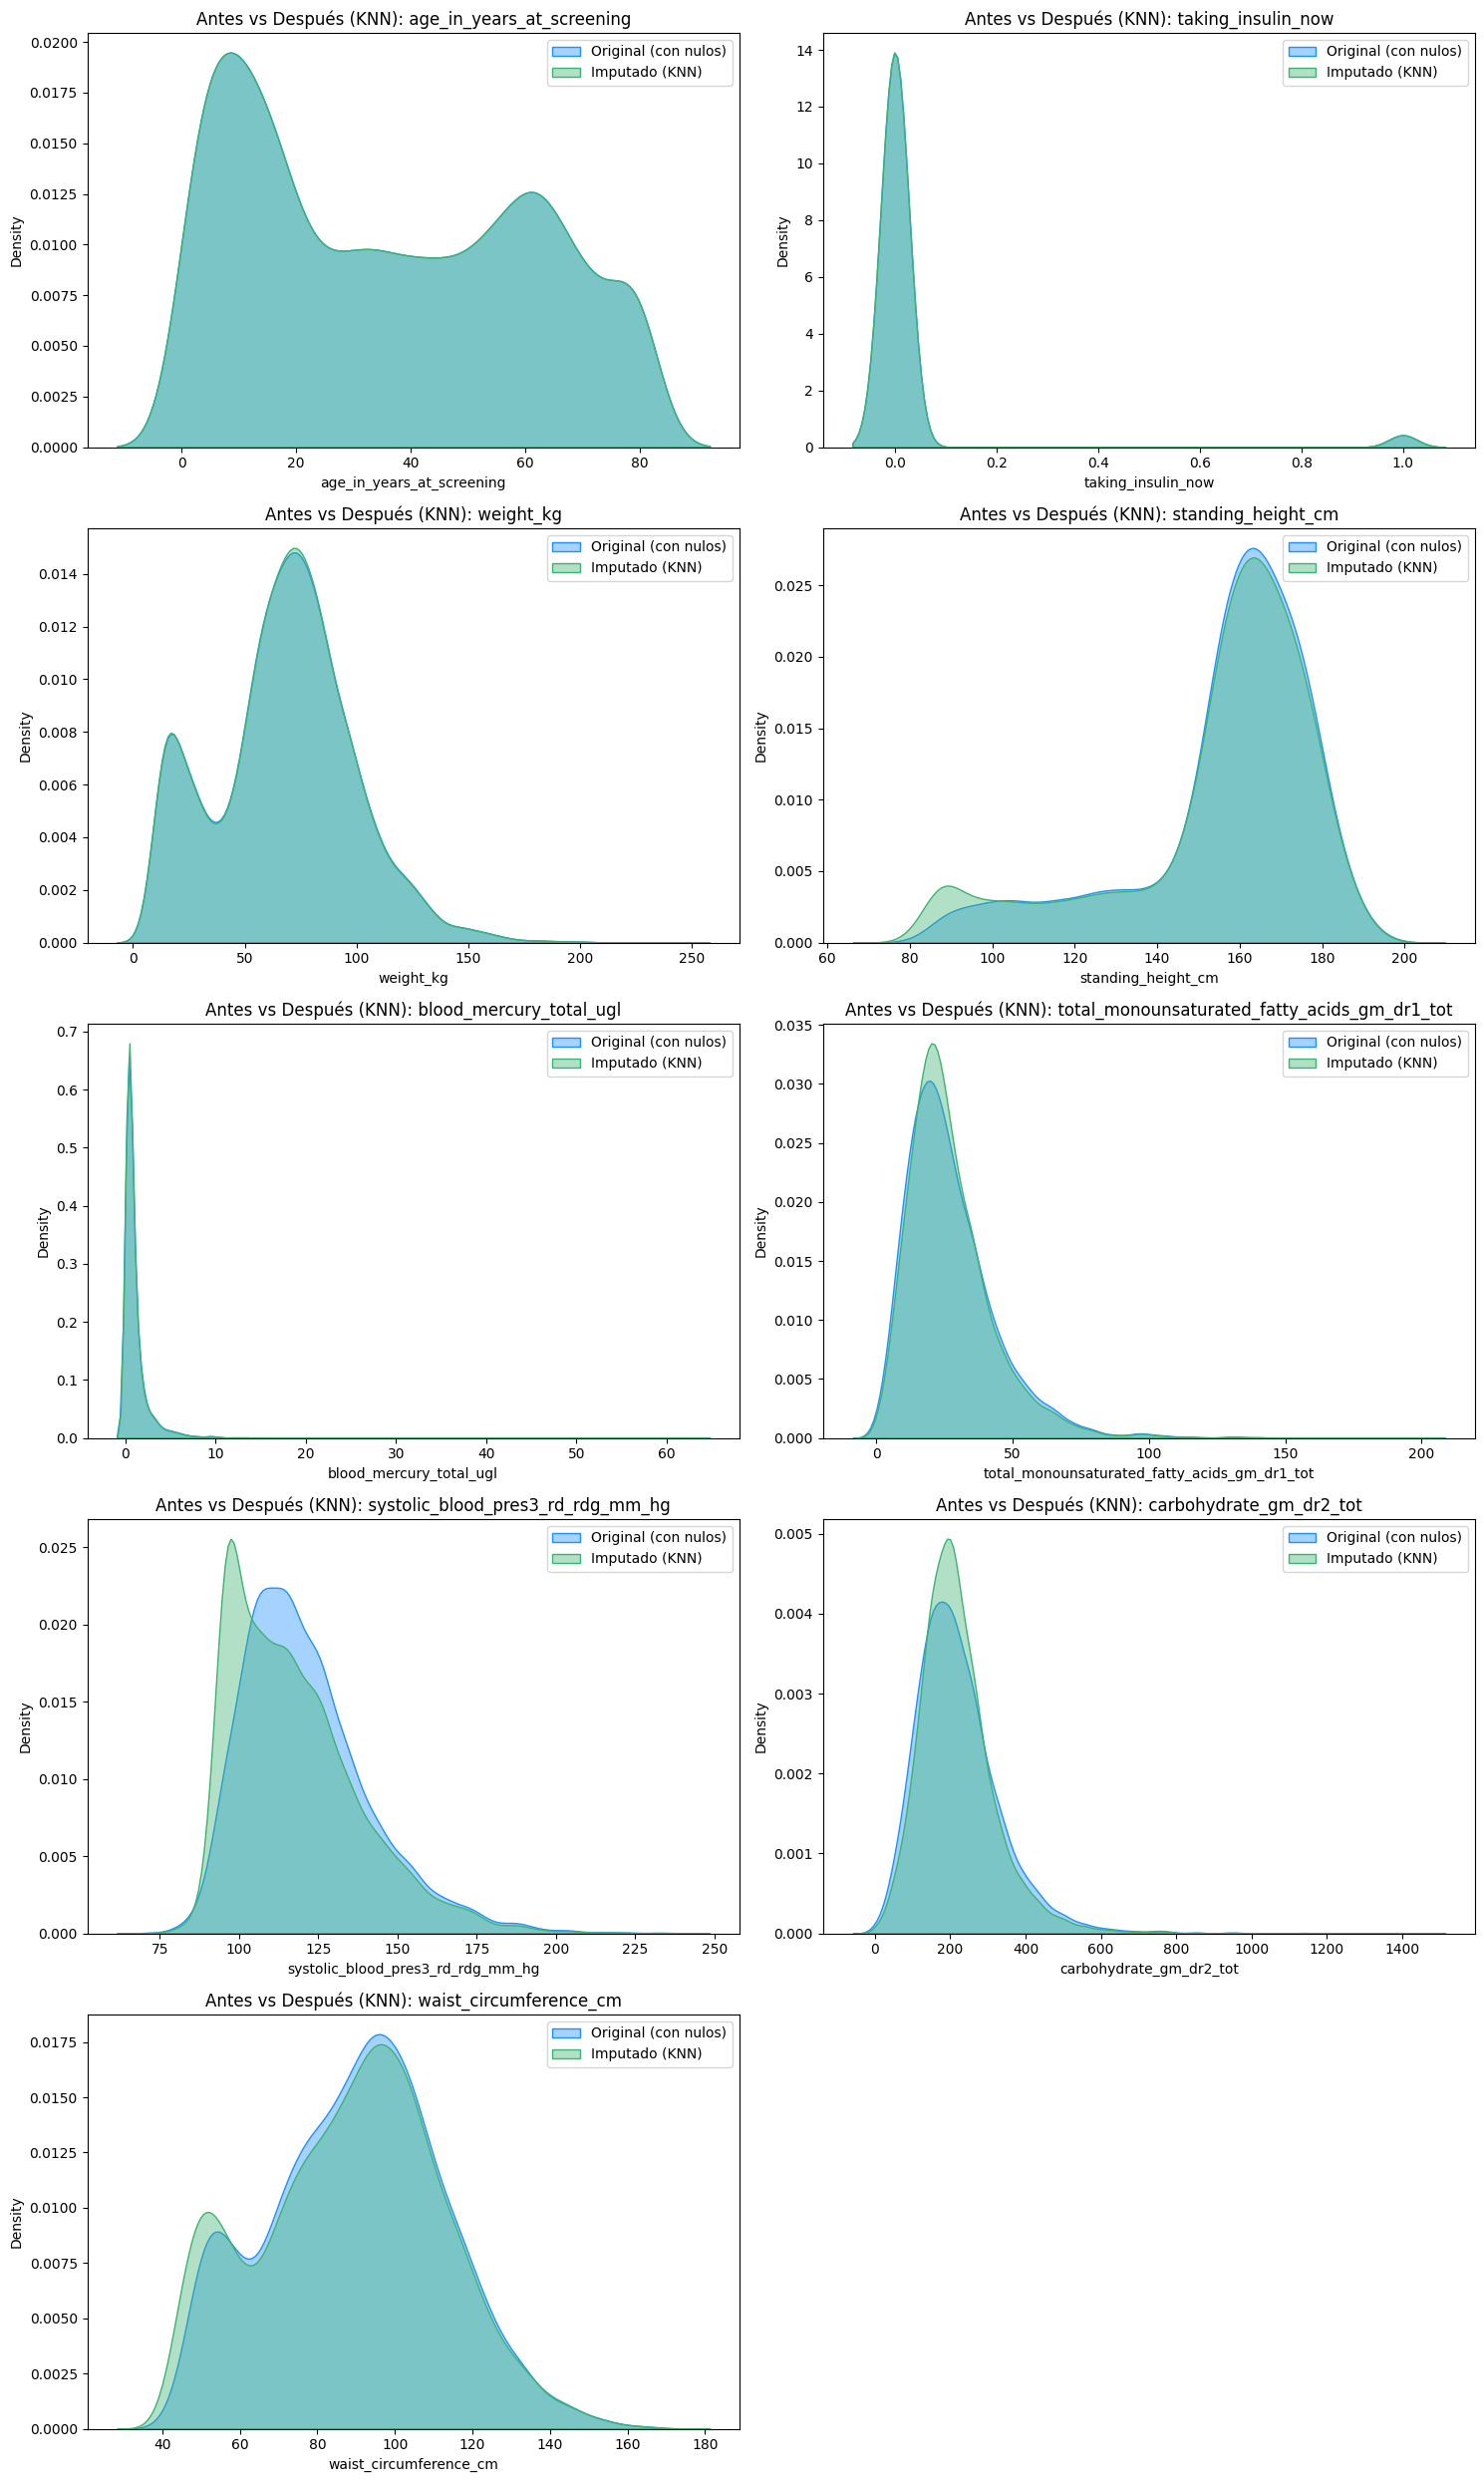

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# 1. Tomar solo las variables numéricas del DataFrame original
columnas_a_graficar = df_subset.select_dtypes(include=[np.number]).columns

# 2. Configurar el tamaño del panel según la cantidad de variables
filas = math.ceil(len(columnas_a_graficar) / 2)
fig, axes = plt.subplots(nrows=filas, ncols=2, figsize=(15, 5 * filas))
axes = axes.flatten()

# 3. Graficar el Antes vs Después para cada variable
for i, col in enumerate(columnas_a_graficar):
    # Distribución ORIGINAL (azul)
    sns.kdeplot(data=df_subset, x=col, ax=axes[i], label='Original (con nulos)', color='dodgerblue', fill=True, alpha=0.4)
    
    # Distribución IMPUTADA POR KNN (verde)
    sns.kdeplot(data=df_subset_knn_df, x=col, ax=axes[i], label='Imputado (KNN)', color='mediumseagreen', fill=True, alpha=0.4)
    
    axes[i].set_title(f'Antes vs Después (KNN): {col}', fontsize=12)
    axes[i].legend()

# 4. Ocultar gráficos vacíos si la cantidad de variables es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
#Se puede ver que la imputación por KNN es mucho mejor que la imputación por mediana,
#  ya que las funciones de densidad de probabilidad de las variables imputadas por KNN 
# se parecen mucho más a las funciones de densidad de probabilidad de los datos originales (con nulos) para todas las variables.

In [ ]:
#Impuitación MICE Linear_regressor

from sklearn.linear_model import LinearRegression
from sklearn.experimental import enable_iterative_imputer
import sklearn.impute
import pandas as pd
import numpy as np

# 1. Separamos numéricas y texto (igual que hicimos con KNN)
numeric_cols = df_subset_transformed_df.select_dtypes(include=[np.number]).columns
text_cols = df_subset_transformed_df.select_dtypes(exclude=[np.number]).columns

# 2. Configuramos el imputador MICE
mice_imputer = sklearn.impute.IterativeImputer(
    estimator=LinearRegression(), 
    initial_strategy='mean', 
    max_iter=10,
    random_state=42 # Buena práctica para que los resultados sean reproducibles
)

# 3. Aplicamos MICE SOLO a las numéricas (y quitamos el .round() global)
imputado_mice_numerico = pd.DataFrame(
    mice_imputer.fit_transform(df_subset_transformed_df[numeric_cols]),
    columns=numeric_cols,
    index=df_subset_transformed_df.index
)

# 4. Redondeamos SOLO 'general_health_condition' para que vuelva a ser categoría (0, 1, 2...)
imputado_mice_numerico['general_health_condition'] = imputado_mice_numerico['general_health_condition'].round()

# 5. Volvemos a unir (pegar) nuestras numéricas imputadas con las de texto intactas
df_subset_mice_df = pd.concat([imputado_mice_numerico, df_subset_transformed_df[text_cols]], axis=1)

# Reordenamos las columnas igual que al principio
df_subset_mice_df = df_subset_mice_df[df_subset_transformed_df.columns]

# Verificamos
df_subset_mice_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   general_health_condition                      8366 non-null   float64
 1   total_number_of_people_in_the_family          8366 non-null   str    
 2   age_in_years_at_screening                     8366 non-null   float64
 3   gender                                        8366 non-null   str    
 4   taking_insulin_now                            8366 non-null   float64
 5   weight_kg                                     8366 non-null   float64
 6   standing_height_cm                            8366 non-null   float64
 7   blood_mercury_total_ugl                       8366 non-null   float64
 8   total_monounsaturated_fatty_acids_gm_dr1_tot  8366 non-null   float64
 9   systolic_blood_pres3_rd_rdg_mm_hg             8366 non-null   float64
 10 

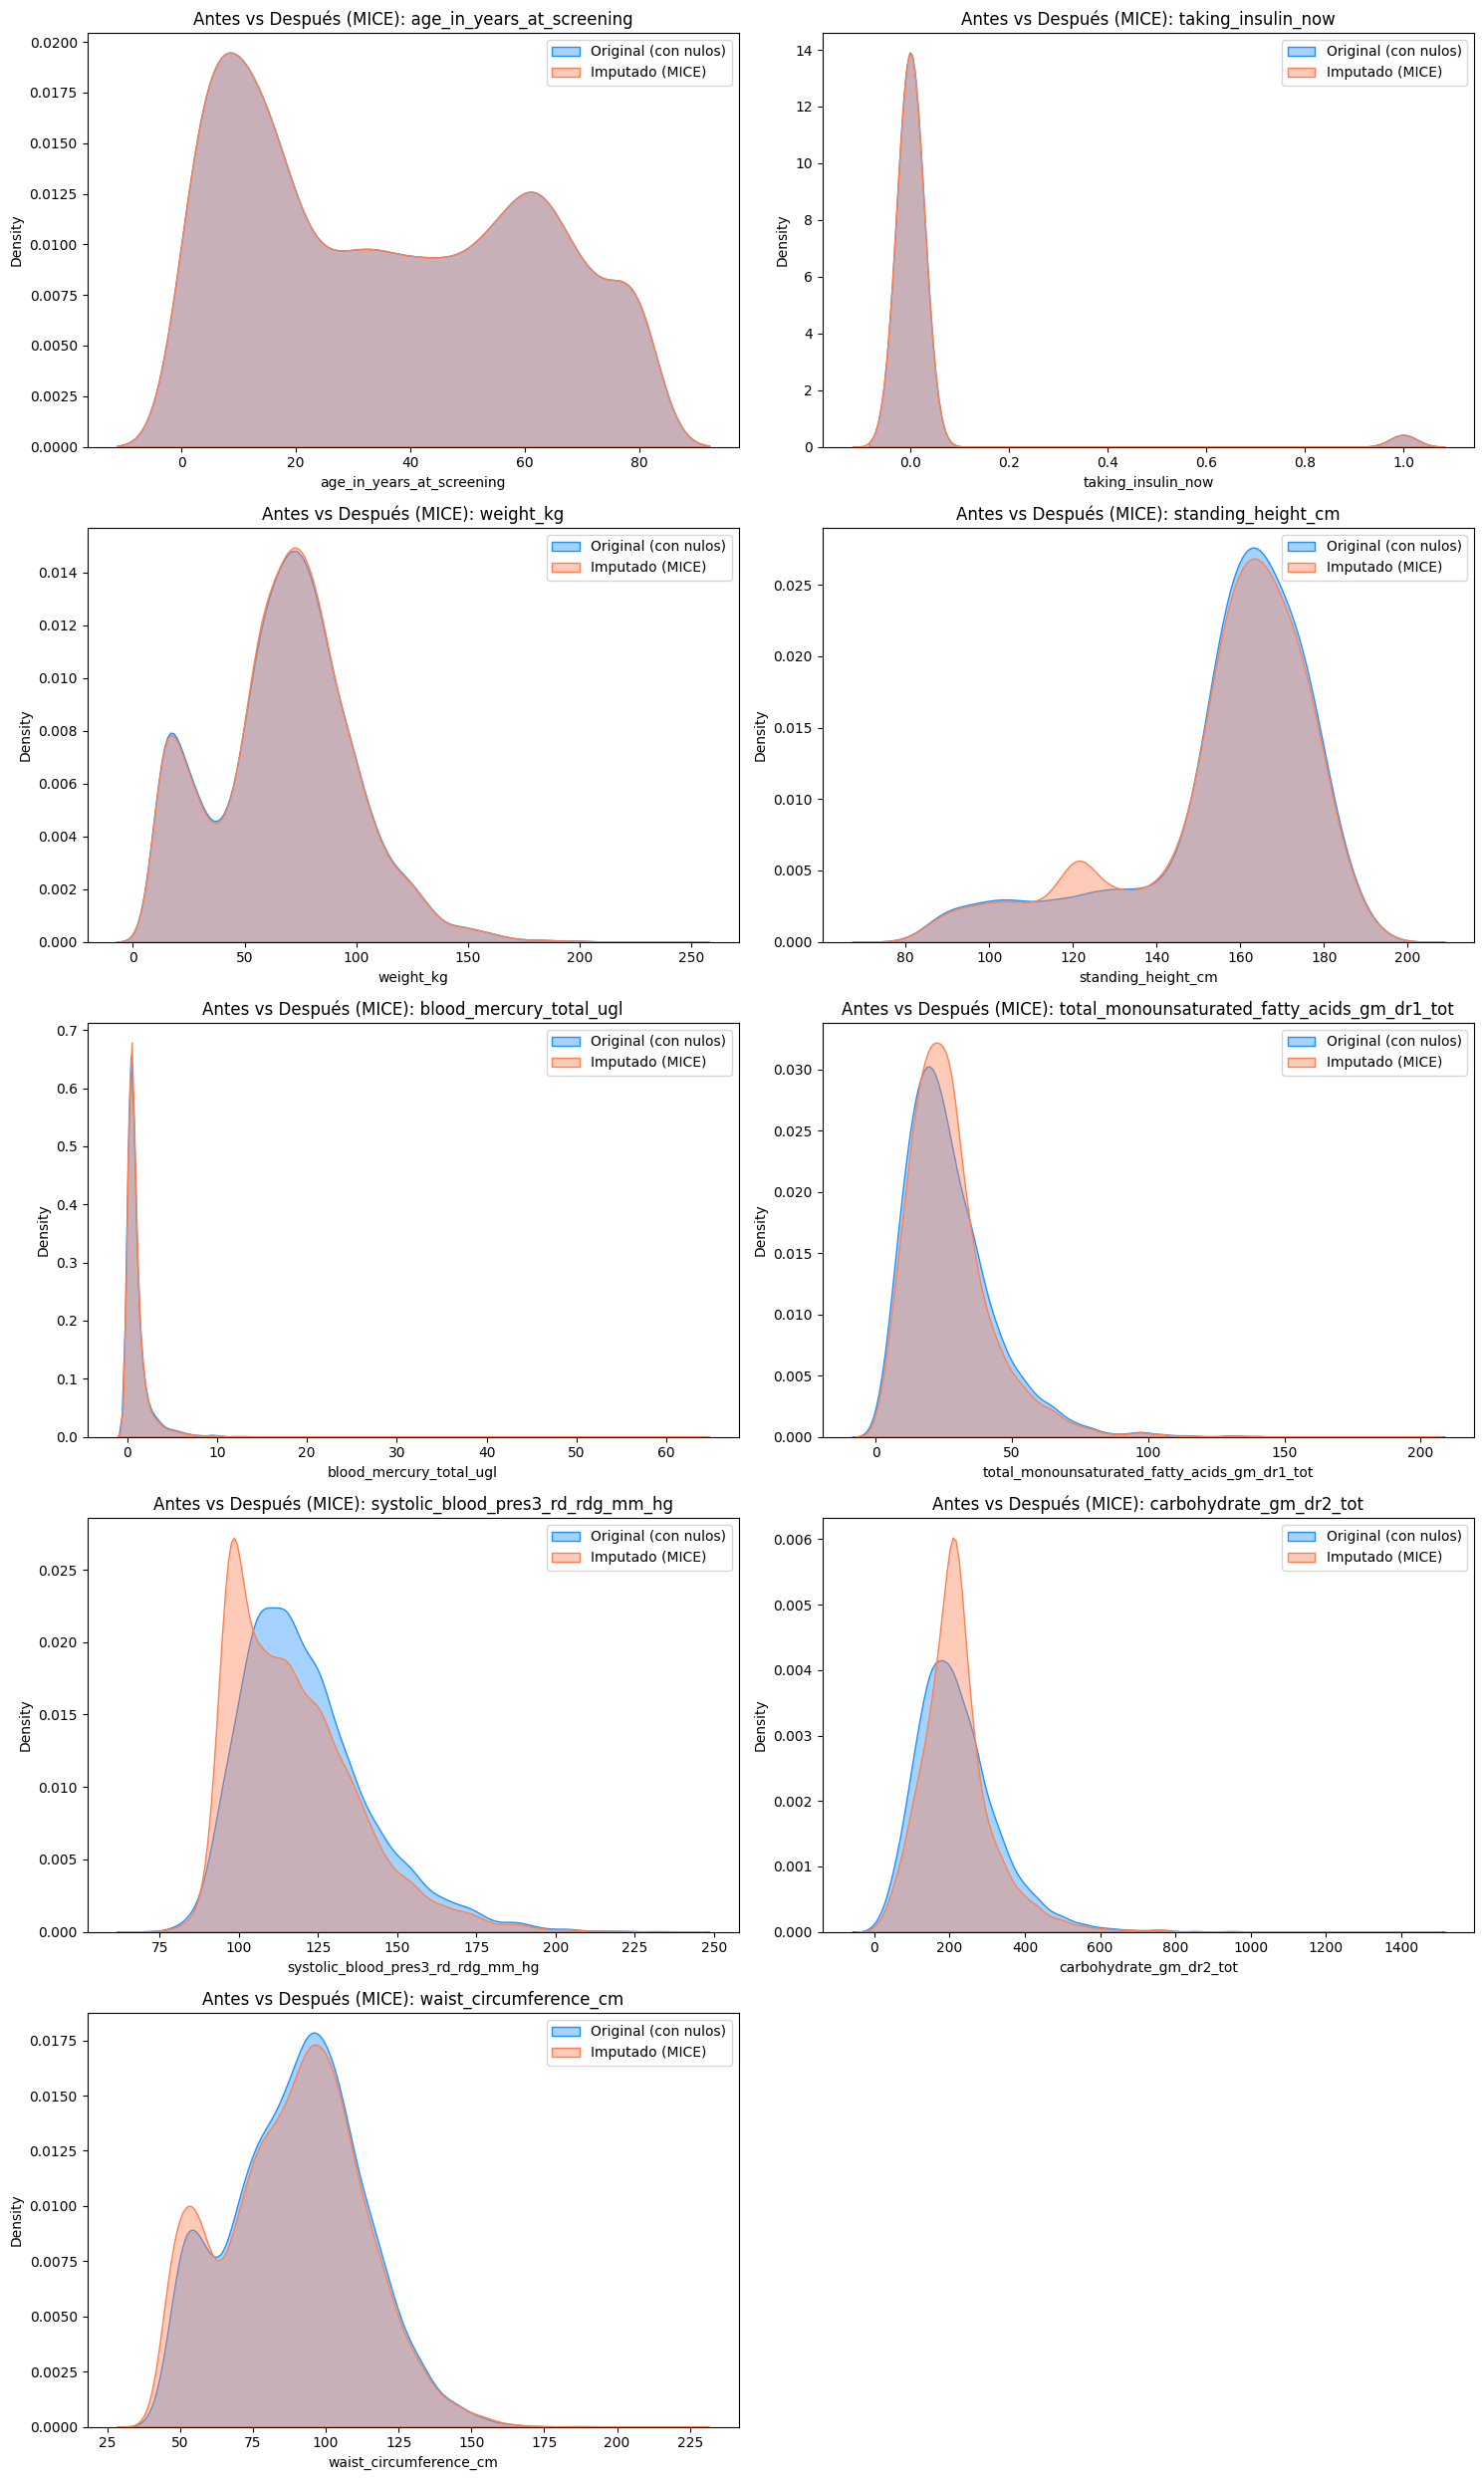

In [177]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# 1. Tomar solo las variables numéricas del DataFrame original
columnas_a_graficar = df_subset.select_dtypes(include=[np.number]).columns

# 2. Configurar el tamaño del panel
filas = math.ceil(len(columnas_a_graficar) / 2)
fig, axes = plt.subplots(nrows=filas, ncols=2, figsize=(15, 5 * filas))
axes = axes.flatten()

# 3. Graficar el Antes vs Después para cada variable
for i, col in enumerate(columnas_a_graficar):
    # Distribución ORIGINAL (azul)
    sns.kdeplot(data=df_subset, x=col, ax=axes[i], label='Original (con nulos)', color='dodgerblue', fill=True, alpha=0.4)
    
    # Distribución IMPUTADA POR MICE (coral)
    sns.kdeplot(data=df_subset_mice_df, x=col, ax=axes[i], label='Imputado (MICE)', color='coral', fill=True, alpha=0.4)
    
    axes[i].set_title(f'Antes vs Después (MICE): {col}', fontsize=12)
    axes[i].legend()

# 4. Ocultar gráficos vacíos si sobran paneles
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
"""

Con MICE esta muy bien pero hay sesgos considerables en systolic_blood_pres3_rd_rdg_mm_hg
y en carbohydrate_gm_dr2_tot

"""

In [ ]:
#Impuitación MICE por decision tree regressor

from sklearn.linear_model import LinearRegression
from sklearn.experimental import enable_iterative_imputer
import sklearn.impute
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer

# 1. Separamos numéricas y texto (igual que hicimos con KNN)
numeric_cols = df_subset_transformed_df.select_dtypes(include=[np.number]).columns
text_cols = df_subset_transformed_df.select_dtypes(exclude=[np.number]).columns

# 2. Configuramos el imputador MICE
mice_imputer = sklearn.impute.IterativeImputer(
    estimator=DecisionTreeRegressor(), 
    initial_strategy='mean', 
    max_iter=10,
    random_state=42 # Buena práctica para que los resultados sean reproducibles
)

# 3. Aplicamos MICE SOLO a las numéricas (y quitamos el .round() global)
imputado_mice_numerico = pd.DataFrame(
    mice_imputer.fit_transform(df_subset_transformed_df[numeric_cols]),
    columns=numeric_cols,
    index=df_subset_transformed_df.index
)

# 4. Redondeamos SOLO 'general_health_condition' para que vuelva a ser categoría (0, 1, 2...)
imputado_mice_numerico['general_health_condition'] = imputado_mice_numerico['general_health_condition'].round()

# 5. Volvemos a unir (pegar) nuestras numéricas imputadas con las de texto intactas
df_subset_mice_df = pd.concat([imputado_mice_numerico, df_subset_transformed_df[text_cols]], axis=1)

# Reordenamos las columnas igual que al principio
df_subset_mice_df = df_subset_mice_df[df_subset_transformed_df.columns]

# Verificamos
df_subset_mice_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   general_health_condition                      8366 non-null   float64
 1   total_number_of_people_in_the_family          8366 non-null   str    
 2   age_in_years_at_screening                     8366 non-null   float64
 3   gender                                        8366 non-null   str    
 4   taking_insulin_now                            8366 non-null   float64
 5   weight_kg                                     8366 non-null   float64
 6   standing_height_cm                            8366 non-null   float64
 7   blood_mercury_total_ugl                       8366 non-null   float64
 8   total_monounsaturated_fatty_acids_gm_dr1_tot  8366 non-null   float64
 9   systolic_blood_pres3_rd_rdg_mm_hg             8366 non-null   float64
 10 

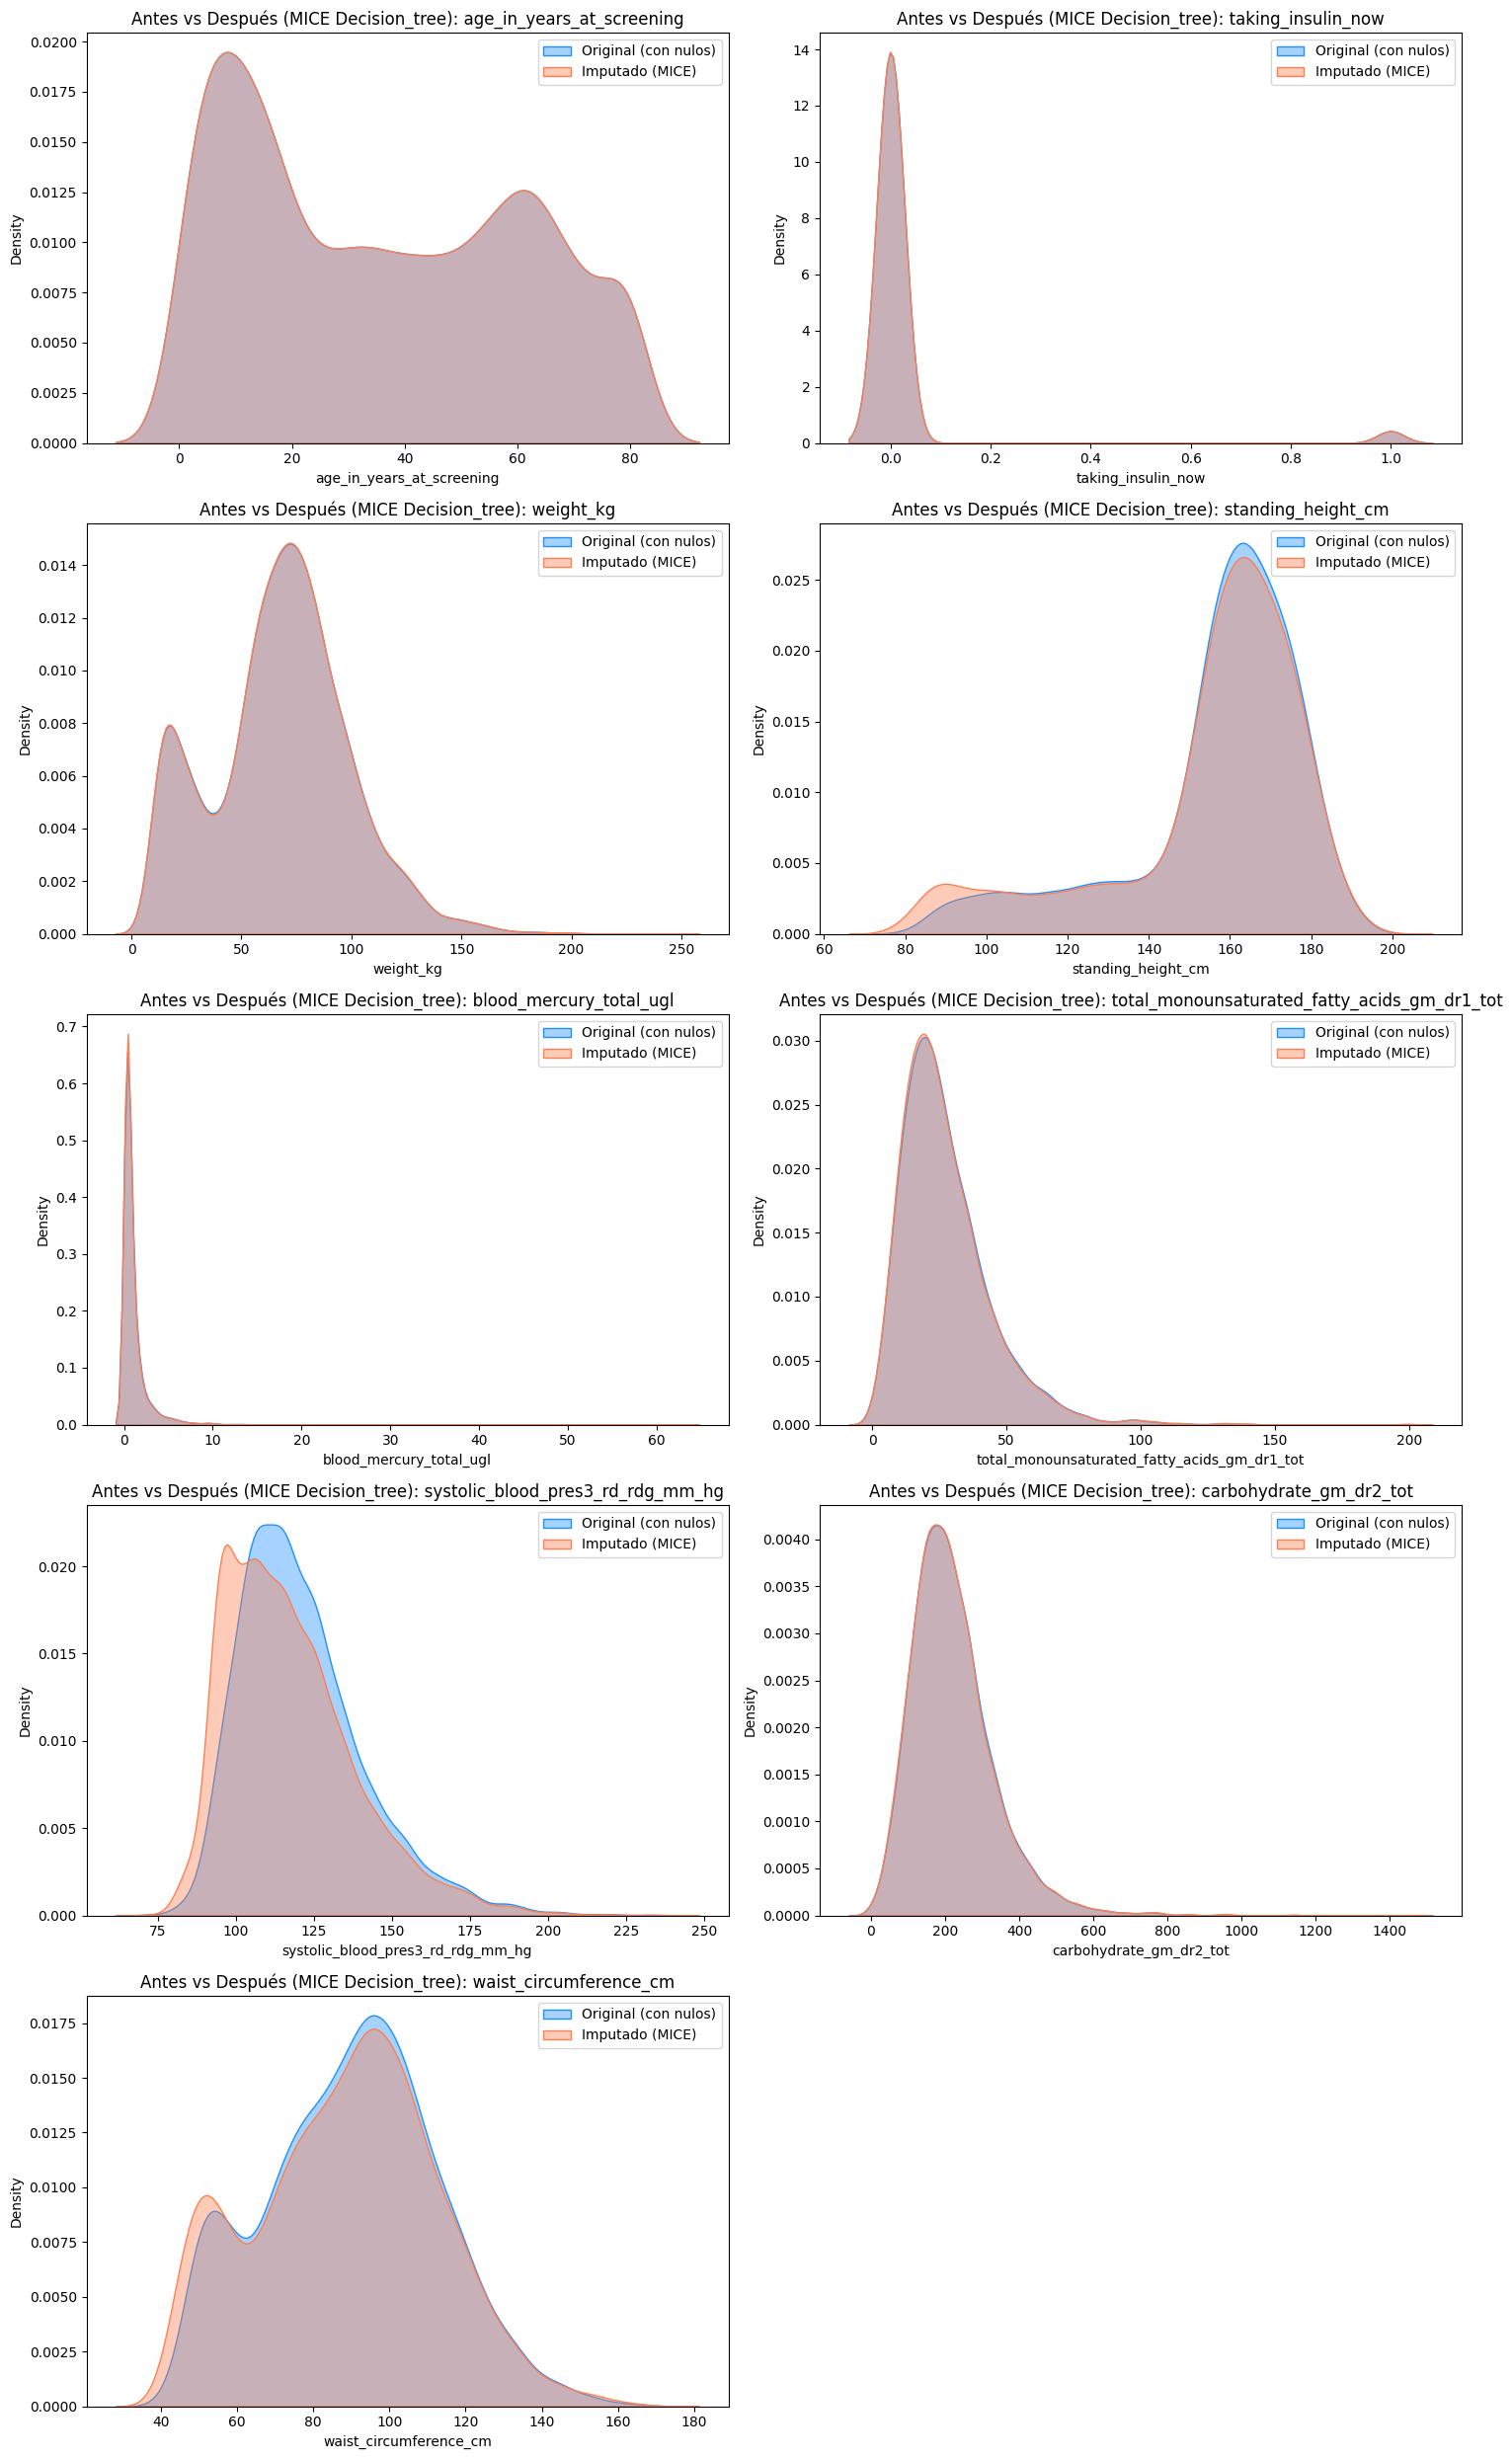

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# 1. Tomar solo las variables numéricas del DataFrame original
columnas_a_graficar = df_subset.select_dtypes(include=[np.number]).columns

# 2. Configurar el tamaño del panel
filas = math.ceil(len(columnas_a_graficar) / 2)
fig, axes = plt.subplots(nrows=filas, ncols=2, figsize=(15, 5 * filas))
axes = axes.flatten()

# 3. Graficar el Antes vs Después para cada variable
for i, col in enumerate(columnas_a_graficar):
    # Distribución ORIGINAL (azul)
    sns.kdeplot(data=df_subset, x=col, ax=axes[i], label='Original (con nulos)', color='dodgerblue', fill=True, alpha=0.4)
    
    # Distribución IMPUTADA POR MICE (coral)
    sns.kdeplot(data=df_subset_mice_df, x=col, ax=axes[i], label='Imputado (MICE)', color='coral', fill=True, alpha=0.4)
    
    axes[i].set_title(f'Antes vs Después (MICE Decision_tree): {col}', fontsize=12)
    axes[i].legend()

# 4. Ocultar gráficos vacíos si sobran paneles
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
"""

Aca mejoro bastante, solo systolic_blood_pres3_rd_rdg_mm_hg

las demas están muy bien

"""

In [181]:
#Impuitación MICE por Random F0rest Regressor

from sklearn.linear_model import LinearRegression
from sklearn.experimental import enable_iterative_imputer
import sklearn.impute
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer

# 1. Separamos numéricas y texto (igual que hicimos con KNN)
numeric_cols = df_subset_transformed_df.select_dtypes(include=[np.number]).columns
text_cols = df_subset_transformed_df.select_dtypes(exclude=[np.number]).columns

# 2. Configuramos el imputador MICE
mice_imputer = sklearn.impute.IterativeImputer(
    estimator=RandomForestRegressor(), 
    initial_strategy='mean', 
    max_iter=10,
    random_state=42 # Buena práctica para que los resultados sean reproducibles
)

# 3. Aplicamos MICE SOLO a las numéricas (y quitamos el .round() global)
imputado_mice_numerico = pd.DataFrame(
    mice_imputer.fit_transform(df_subset_transformed_df[numeric_cols]),
    columns=numeric_cols,
    index=df_subset_transformed_df.index
)

# 4. Redondeamos SOLO 'general_health_condition' para que vuelva a ser categoría (0, 1, 2...)
imputado_mice_numerico['general_health_condition'] = imputado_mice_numerico['general_health_condition'].round()

# 5. Volvemos a unir (pegar) nuestras numéricas imputadas con las de texto intactas
df_subset_mice_df = pd.concat([imputado_mice_numerico, df_subset_transformed_df[text_cols]], axis=1)

# Reordenamos las columnas igual que al principio
df_subset_mice_df = df_subset_mice_df[df_subset_transformed_df.columns]

# Verificamos
df_subset_mice_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   general_health_condition                      8366 non-null   float64
 1   total_number_of_people_in_the_family          8366 non-null   str    
 2   age_in_years_at_screening                     8366 non-null   float64
 3   gender                                        8366 non-null   str    
 4   taking_insulin_now                            8366 non-null   float64
 5   weight_kg                                     8366 non-null   float64
 6   standing_height_cm                            8366 non-null   float64
 7   blood_mercury_total_ugl                       8366 non-null   float64
 8   total_monounsaturated_fatty_acids_gm_dr1_tot  8366 non-null   float64
 9   systolic_blood_pres3_rd_rdg_mm_hg             8366 non-null   float64
 10 

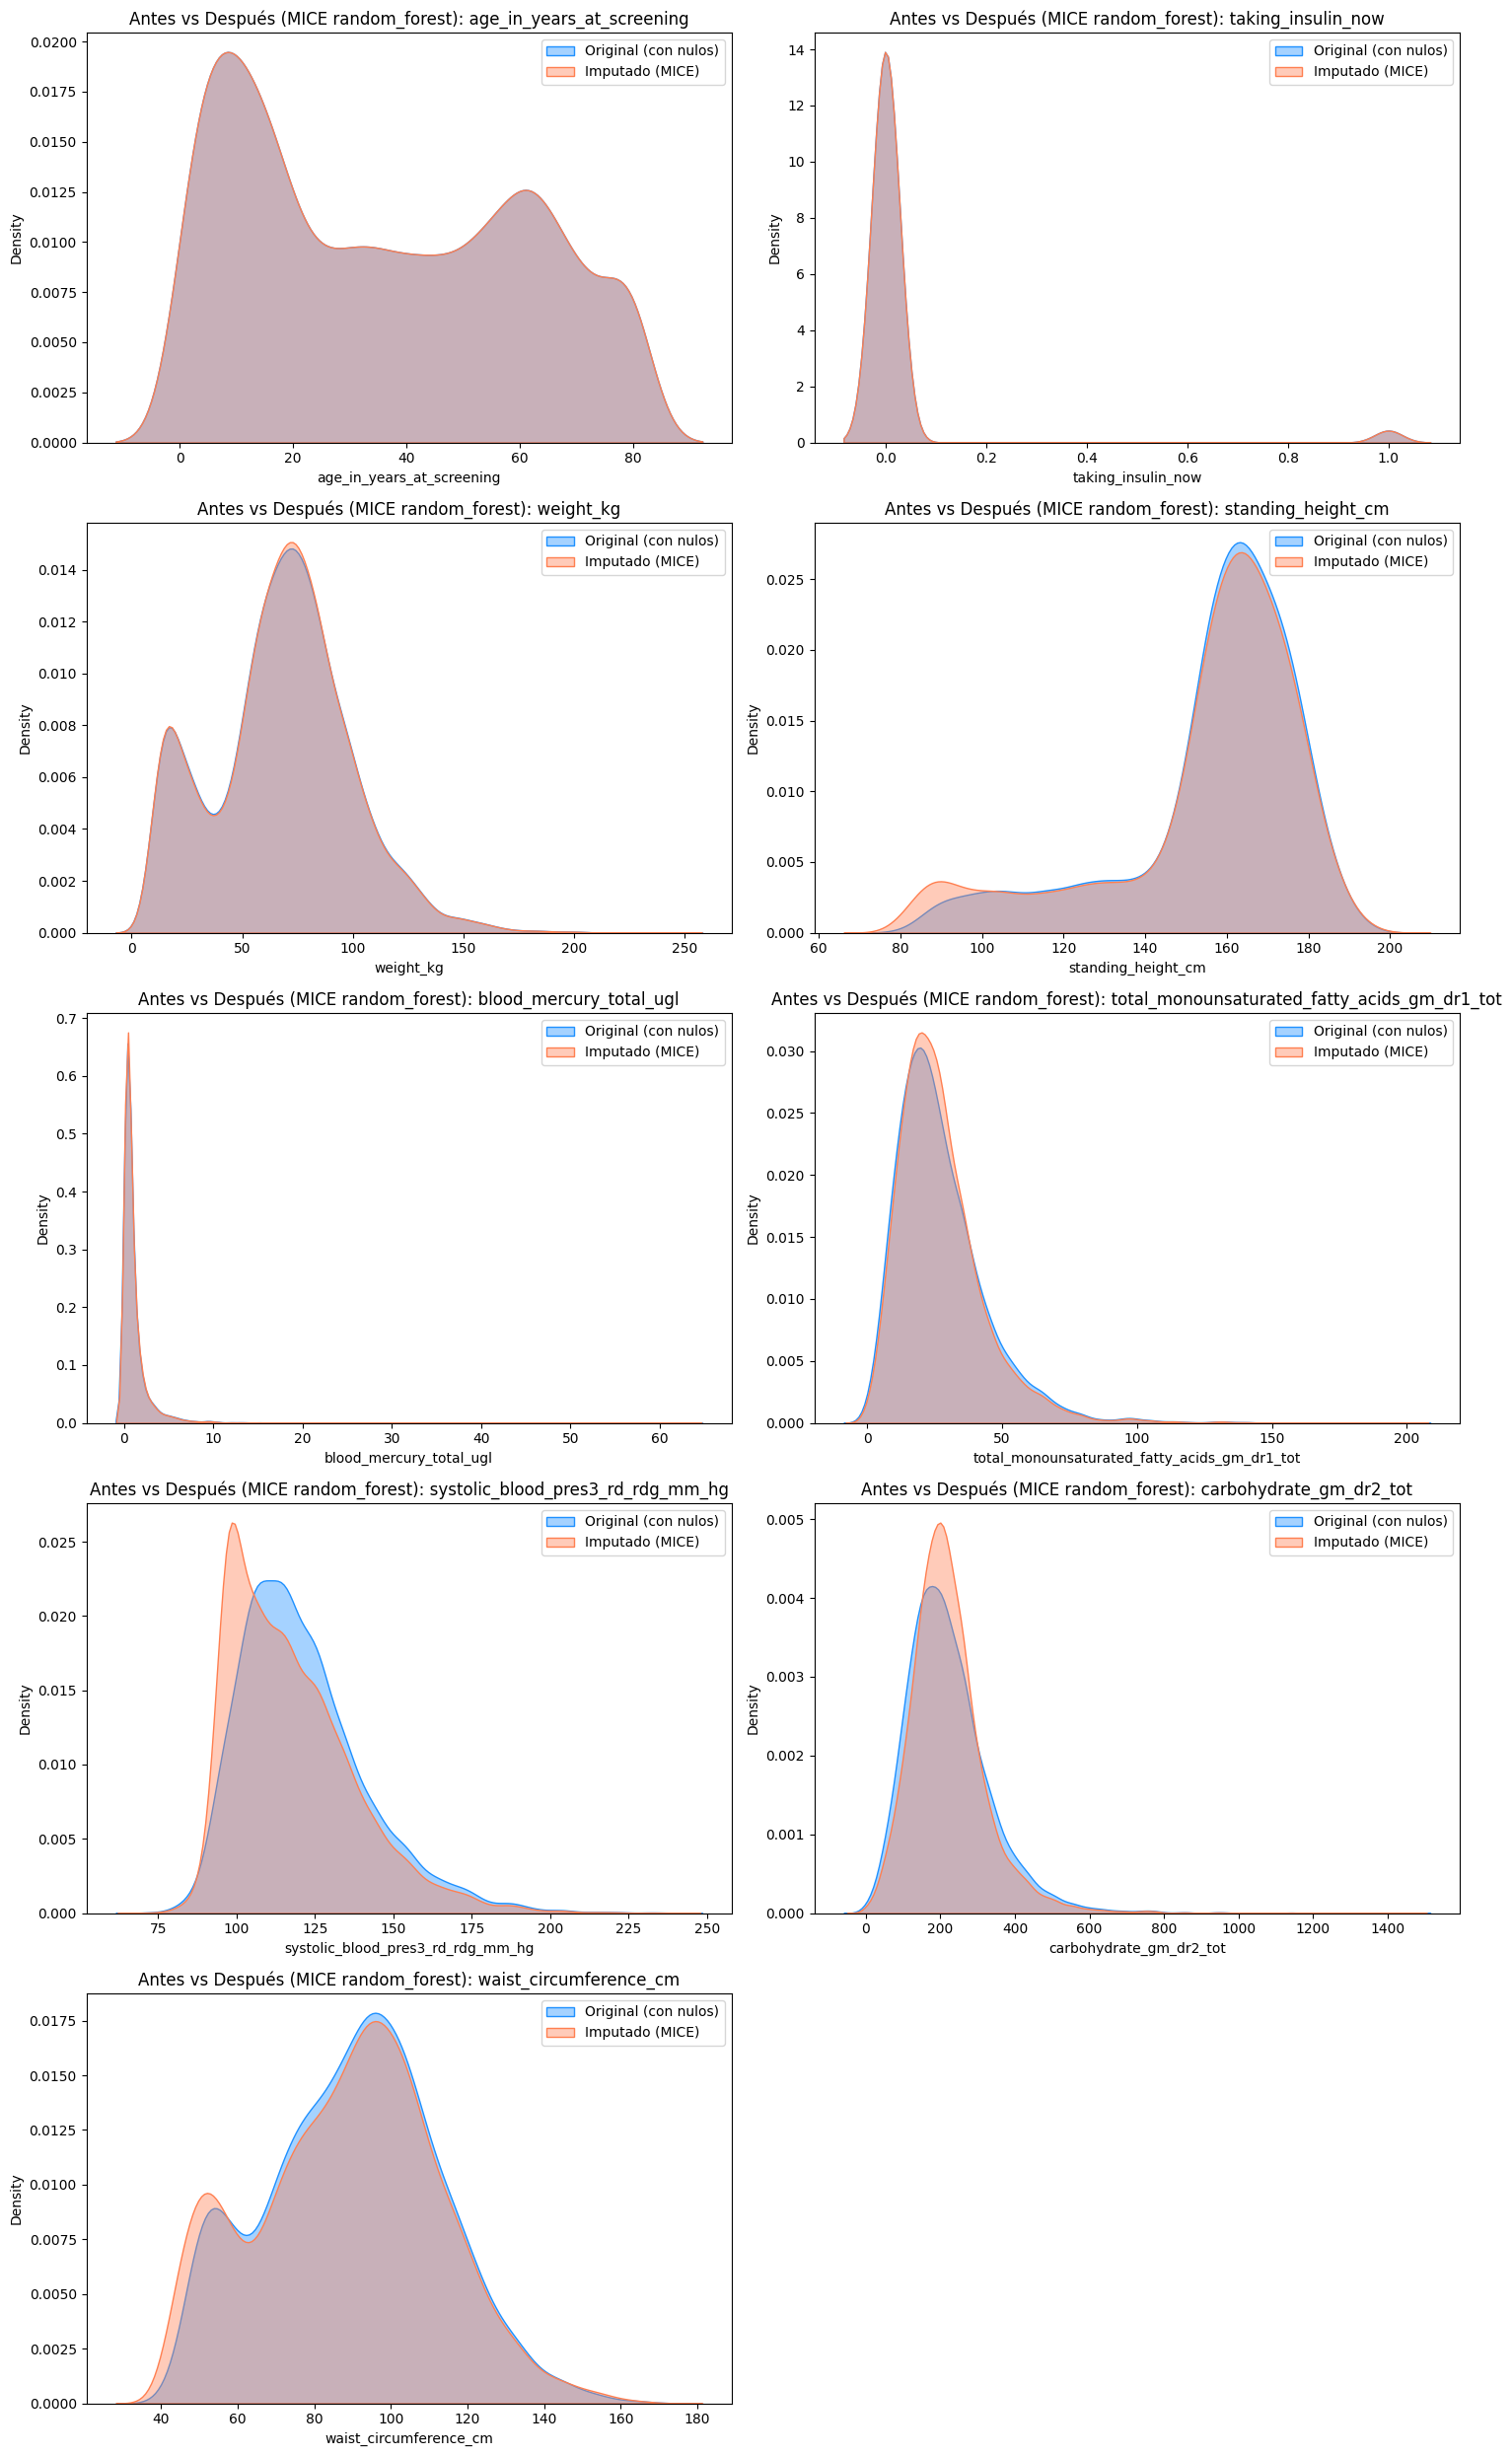

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# 1. Tomar solo las variables numéricas del DataFrame original
columnas_a_graficar = df_subset.select_dtypes(include=[np.number]).columns

# 2. Configurar el tamaño del panel
filas = math.ceil(len(columnas_a_graficar) / 2)
fig, axes = plt.subplots(nrows=filas, ncols=2, figsize=(15, 5 * filas))
axes = axes.flatten()

# 3. Graficar el Antes vs Después para cada variable
for i, col in enumerate(columnas_a_graficar):
    # Distribución ORIGINAL (azul)
    sns.kdeplot(data=df_subset, x=col, ax=axes[i], label='Original (con nulos)', color='dodgerblue', fill=True, alpha=0.4)
    
    # Distribución IMPUTADA POR MICE (coral)
    sns.kdeplot(data=df_subset_mice_df, x=col, ax=axes[i], label='Imputado (MICE)', color='coral', fill=True, alpha=0.4)
    
    axes[i].set_title(f'Antes vs Después (MICE random_forest): {col}', fontsize=12)
    axes[i].legend()

# 4. Ocultar gráficos vacíos si sobran paneles
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
"""
 bien pero hay sesgos considerables en systolic_blood_pres3_rd_rdg_mm_hg
y en carbohydrate_gm_dr2_tot
"""

In [184]:
# red neuronal:

from sklearn.neural_network import MLPRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import StandardScaler
import sklearn.impute
import pandas as pd
import numpy as np

# 1. Separamos numéricas y texto (dejando el texto intacto)
numeric_cols = df_subset_transformed_df.select_dtypes(include=[np.number]).columns
text_cols = df_subset_transformed_df.select_dtypes(exclude=[np.number]).columns

datos_numericos = df_subset_transformed_df[numeric_cols]

# 2. ESCALAMOS los datos numéricos (Obligatorio para Redes Neuronales)
# El scaler es lo suficientemente inteligente para ignorar los NaN al calcular las escalas
scaler = StandardScaler()
datos_numericos_escalados = scaler.fit_transform(datos_numericos)

# 3. Configuramos el imputador MICE con MLPRegressor
# Nota: Le doy max_iter=500 al MLPRegressor para darle tiempo de converger internamente
mlp = MLPRegressor(random_state=42, max_iter=500)

mice_imputer = sklearn.impute.IterativeImputer(
    estimator=mlp, 
    initial_strategy='mean', 
    max_iter=10,
    random_state=42
)

# Aplicamos MICE a los datos ESCALADOS
imputado_escalado = mice_imputer.fit_transform(datos_numericos_escalados)

# 4. DES-ESCALAMOS los datos para recuperar los valores reales (pesos, edades reales, etc.)
imputado_original_scale = scaler.inverse_transform(imputado_escalado)

# Lo convertimos a DataFrame para poder manipularlo
imputado_mice_numerico = pd.DataFrame(
    imputado_original_scale,
    columns=numeric_cols,
    index=df_subset_transformed_df.index
)

# 5. Redondeamos SOLO 'general_health_condition' para que vuelva a ser categoría (0, 1, 2...)
imputado_mice_numerico['general_health_condition'] = imputado_mice_numerico['general_health_condition'].round()

# 6. Volvemos a unir (pegar) nuestras numéricas imputadas con las de texto intactas
df_subset_mlp_df = pd.concat([imputado_mice_numerico, df_subset_transformed_df[text_cols]], axis=1)

# Reordenamos las columnas igual que al principio
df_subset_mlp_df = df_subset_mlp_df[df_subset_transformed_df.columns]

# Verificamos
df_subset_mlp_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 12 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   general_health_condition                      8366 non-null   float64
 1   total_number_of_people_in_the_family          8366 non-null   str    
 2   age_in_years_at_screening                     8366 non-null   float64
 3   gender                                        8366 non-null   str    
 4   taking_insulin_now                            8366 non-null   float64
 5   weight_kg                                     8366 non-null   float64
 6   standing_height_cm                            8366 non-null   float64
 7   blood_mercury_total_ugl                       8366 non-null   float64
 8   total_monounsaturated_fatty_acids_gm_dr1_tot  8366 non-null   float64
 9   systolic_blood_pres3_rd_rdg_mm_hg             8366 non-null   float64
 10 

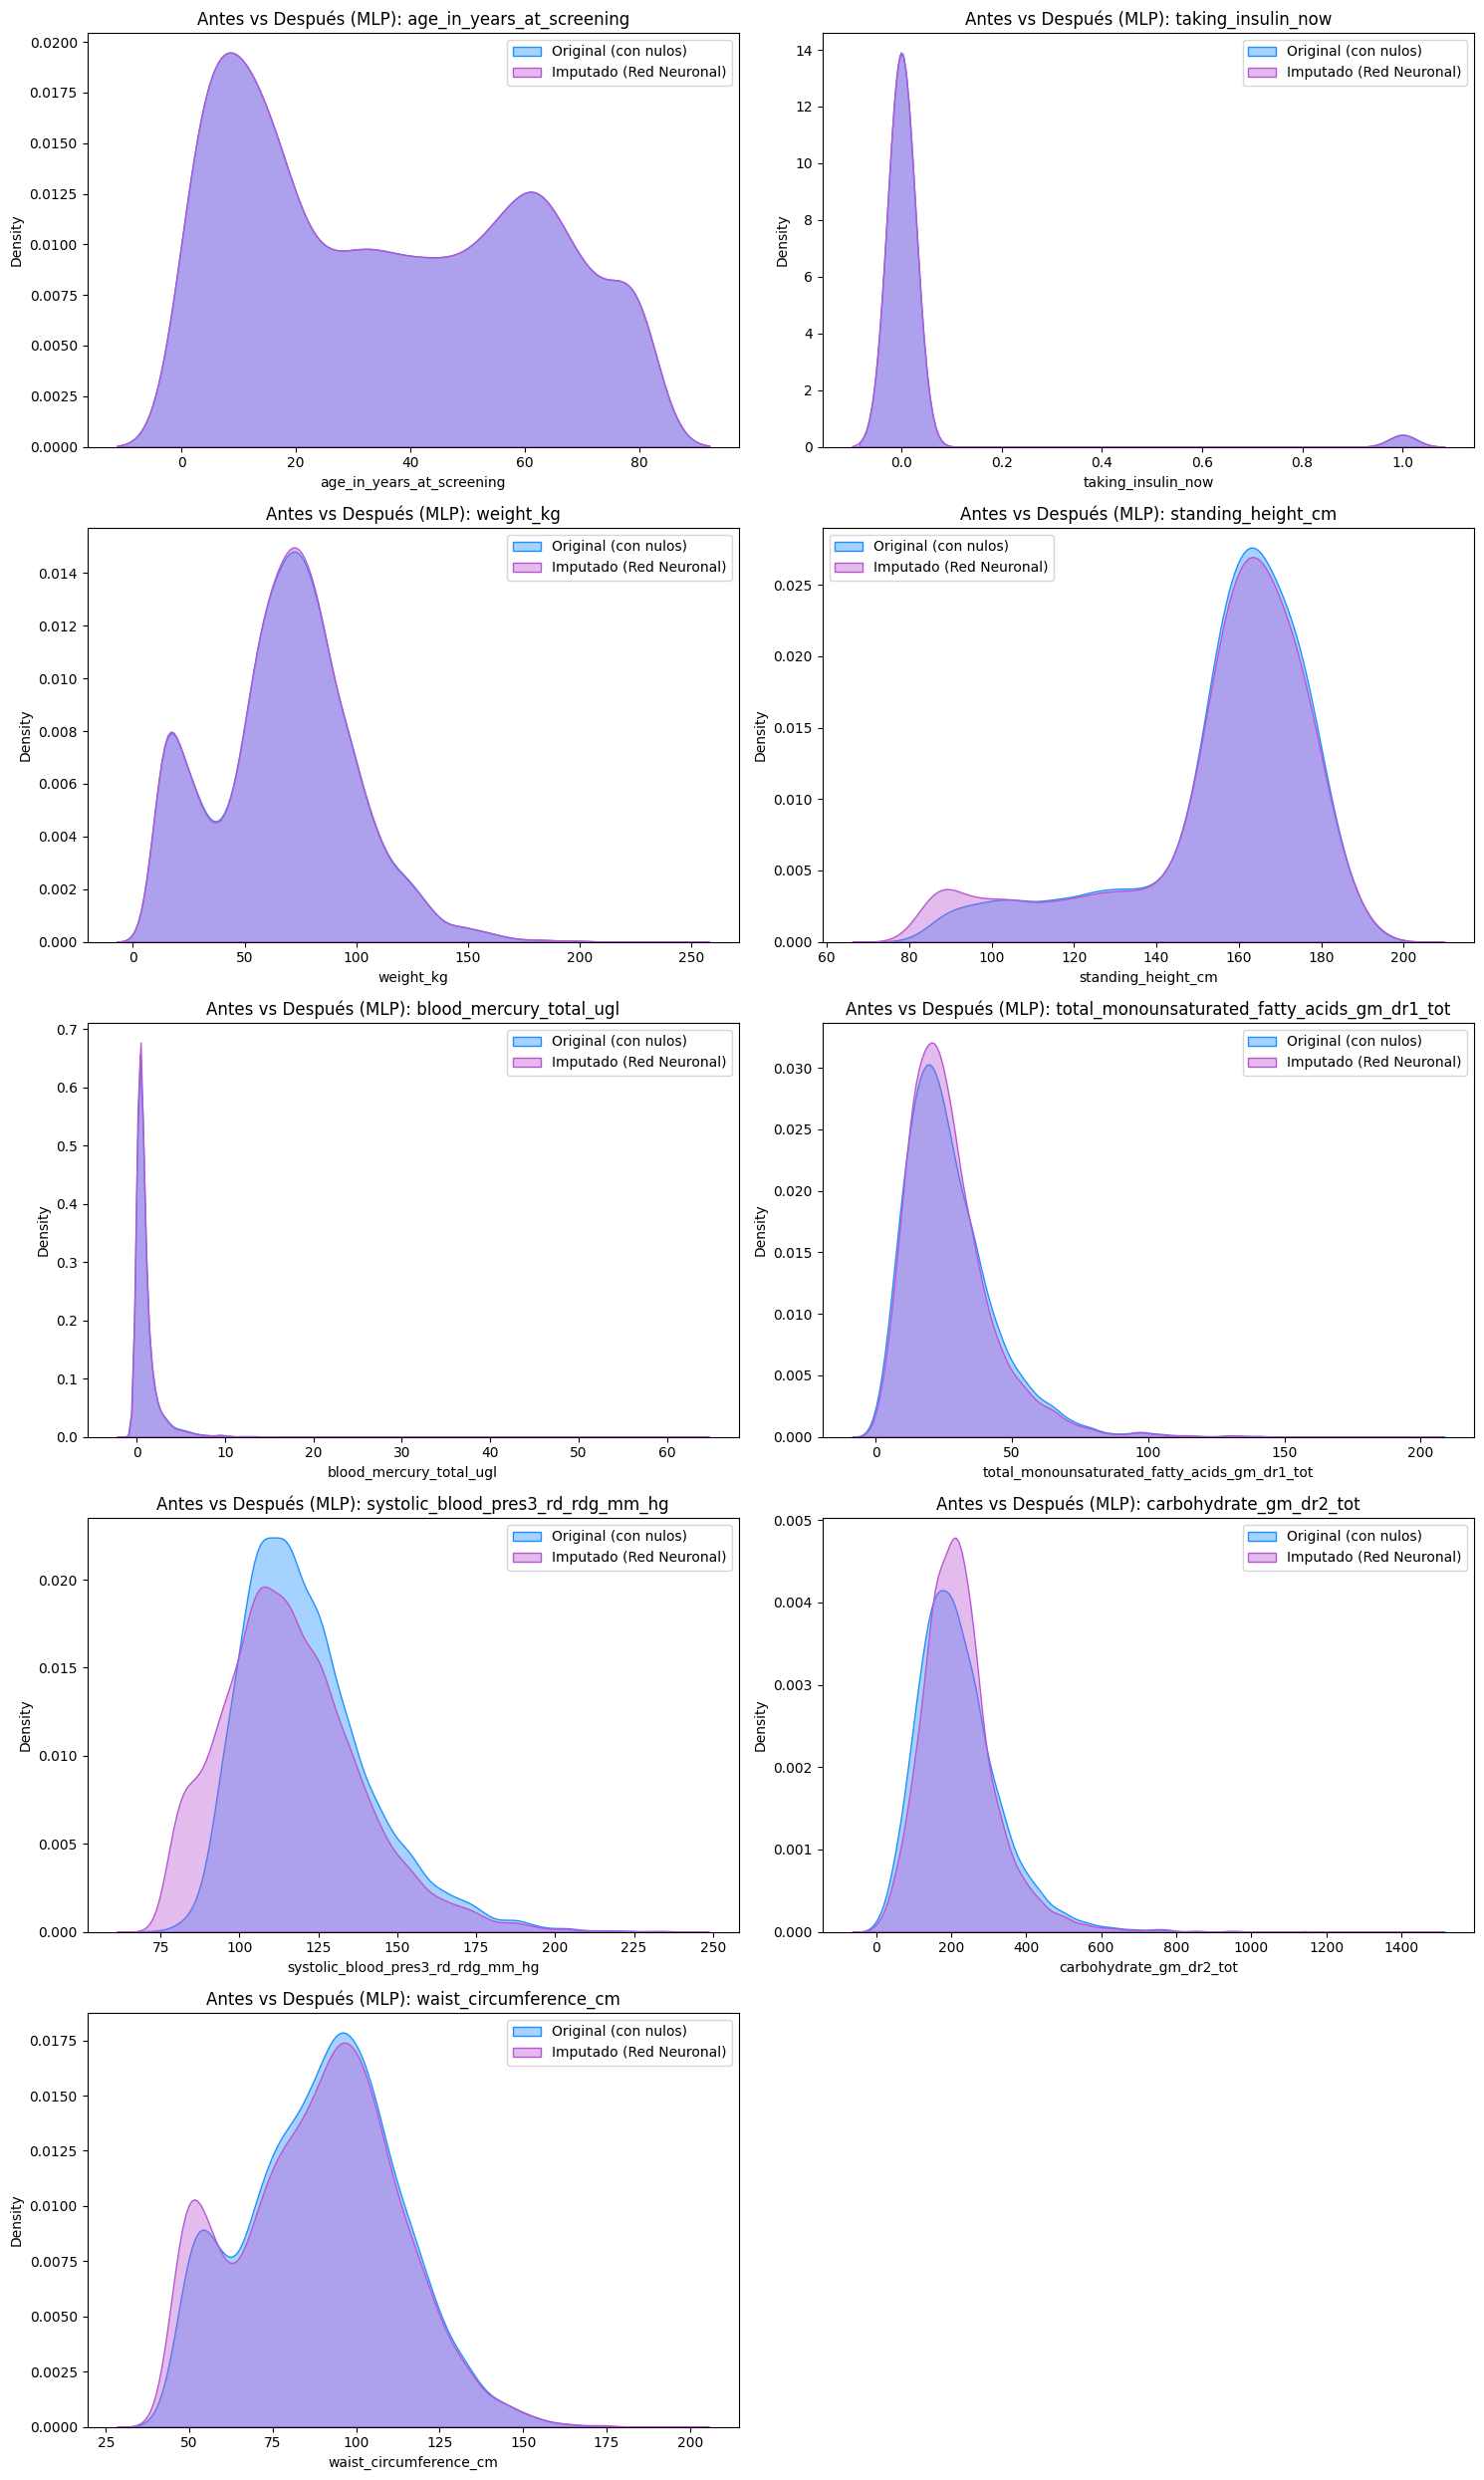

In [185]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# 1. Tomar solo las variables numéricas
columnas_a_graficar = df_subset.select_dtypes(include=[np.number]).columns

# 2. Configurar el tamaño del panel
filas = math.ceil(len(columnas_a_graficar) / 2)
fig, axes = plt.subplots(nrows=filas, ncols=2, figsize=(15, 5 * filas))
axes = axes.flatten()

# 3. Graficar el Antes vs Después (Red Neuronal)
for i, col in enumerate(columnas_a_graficar):
    # Distribución ORIGINAL (azul)
    sns.kdeplot(data=df_subset, x=col, ax=axes[i], label='Original (con nulos)', color='dodgerblue', fill=True, alpha=0.4)
    
    # Distribución IMPUTADA POR MLP (morado)
    sns.kdeplot(data=df_subset_mlp_df, x=col, ax=axes[i], label='Imputado (Red Neuronal)', color='mediumorchid', fill=True, alpha=0.4)
    
    axes[i].set_title(f'Antes vs Después (MLP): {col}', fontsize=12)
    axes[i].legend()

# 4. Ocultar gráficos vacíos si sobran paneles
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Tambien se equivocó mucho en systolic_blood_pres3_rd_rdg_mm_hg.

***Ganó decision trees***